# College of Computing and Informatics, Drexel University
## INFO 371: Data Mining Applications
### Due: June 1, 2026
---

## Final Project Report

## Project Title: Anime Recommendation System

## Student(s): Byron McBorrough, Keith Woods, Anel Tolegen

#### Date: 6/1/2026
---

# Requirements:
1. **Formatting and Structure**:
The report must follow a clear, logical structure (use headings, subheadings, markdown cells, and code cells for organization).
2. **Code and Results**:
Include all code in code cells. Ensure the code is clean, readable, and uses proper commenting where necessary.
3. **Explanations**: Use markdown cells to clearly explain each step of the analysis, modeling, and evaluation process. Provide context for the code being executed. Interpret the results (e.g., what do the visualizations show? What models do you choose? How do you evaluate the results? What insights can be drawn?).
4. **Reproducibility**:
Provide all code and commands necessary for reproducing your analysis. Ensure all data imports, transformations, and analyses run correctly in sequence.

# Marking Scheme:
- **Organization and Formatting (10 points)**: Is the notebook well-structured and visually clean?
- **Reproducibility (10 points)**: Can the entire analysis be reproduced seamlessly?
- **Code Quality (20 points)**: Is the code clear, concise, and well-documented?
- **Explanations and Insights (20 points)**: Are steps and results well-explained and insightful?
- **Data Visualization and Presentation (20 points)**: Are plots and tables effective and well-labeled?
- **Technical Content (20 points)**:
 * Is the problem well defined and described thoroughly?
 * Is the size and complexity of the data set used in this project comparable to that of the example data sets used in the lectures and assignments?
 * Did the report describe the characteristics of the data?
 * Did the report describe the goals of the data miming?
 * Did the projet use feature engineering and feature selection methods?
 * Did the project build, compare, and evaluate multiple models?
 * Did the report discuss the results and findings?
 * Did the report include all related references?
- **Only those projects that exceed the sophistication of the data mining examples in the lectures and assignments can be marked as the highest level of grade**.
- **Overall, what is the rating of this project?**

# YOUR REPORT GOES HERE

# 1. Introduction
---
- Introduce the project and describe the objectives.
- State the main questions or problems you aim to address with your project.
- Provide a summary of the entire project, including the data, analytics methods, machine learning techniques, and key findings.

With the rapid growth of digital entertainment platforms, recommendation systems have become an essential tool for helping users discover content that matches their interests. Modern recommendation systems are used across a wide range of industries, including streaming services, e-commerce platforms, social media applications, and online gaming communities. As the volume of available content continues to increase, users often face information overload, making personalized recommendations increasingly valuable.

Anime is a particularly interesting domain for recommendation systems because of its wide variety of genres, themes, art styles, and target audiences. With thousands of anime titles available, users may struggle to find shows that align with their preferences. Traditional methods such as browsing rankings or popularity lists may not always provide the most relevant suggestions because individual tastes can vary significantly. As a result, personalized recommendation systems can play an important role in helping viewers discover anime that they are more likely to enjoy.

The objective of this project is to explore the development of an anime recommendation framework using data from MyAnimeList, one of the largest online anime communities. Specifically, this project investigates how anime characteristics and user rating behavior can be used to generate personalized recommendations. The project focuses on two common recommendation approaches: collaborative filtering, which utilizes user rating patterns, and content-based filtering, which utilizes anime attributes such as genres, descriptions, popularity metrics, and production information.

Several key questions guide this analysis. First, which anime features provide the most useful information for recommendation? Second, how can user rating behavior be leveraged to identify preference patterns and generate personalized suggestions? Third, what challenges arise when working with large-scale anime and user datasets? Finally, how can collaborative filtering and content-based filtering complement one another to create a more effective recommendation system?

To address these questions, this project utilizes three datasets from the MyAnimeList Kaggle collection: an anime information dataset containing descriptive and popularity-related features, a user details dataset containing demographic and activity information, and a user score dataset containing millions of user-anime rating interactions. The analysis includes data cleaning, preprocessing, exploratory data analysis (EDA), feature engineering, and the design of recommendation models. Exploratory analysis is used to understand data distributions, identify important variables, and uncover relationships between popularity, engagement, and ratings. Feature engineering techniques are then applied to improve the usefulness of the data for recommendation tasks.

The results of the analysis demonstrate that both collaborative filtering and content-based filtering offer valuable strengths for anime recommendation. Collaborative filtering excels at identifying hidden preference patterns from user interactions, while content-based filtering provides recommendations based on similarities between anime characteristics. The findings suggest that a hybrid recommendation approach has the potential to provide more accurate and flexible recommendations than either method alone, particularly when dealing with sparse rating data or newly introduced anime titles. In addition, we also created separate matrix factorization (MF) and k-means user-segmentation models to include the latent factors that exemplify MF models as well as including a separate model for comparison, respectively – where the MF model outperformed all other models in the project.

Overall, this project highlights the importance of combining data-driven analytics with recommendation system methodologies to improve content discovery. The insights gained from the analysis provide a foundation for future work involving hybrid recommendation systems, advanced machine learning techniques, and more sophisticated evaluation methods for personalized anime recommendation.

# 2. Data Description
---
- Data Source: Describe the origin of your dataset. Provide a link if applicable.
- Data Loading: Present the code and methods for acquiring the data. Load the data into appropriate format for analysis.
- Dataset Analysis: Analyze the key attributes and features of your dataset (e.g., number of rows, columns, types of data).
- Data Cleaning: Clean and preprocess the data, including handling missing values or duplicates.

The dataset used in this project comes from Kaggle’s MyAnimeList dataset, which contains three files: `anime-dataset-2023.csv`, `users-details-2023.csv`, and `users-score-2023.csv`. Together, these files provide information about anime titles, user profiles, and user ratings.

The `animeDF` dataframe contains 24,905 rows and 24 columns. It includes anime identifiers, title information, descriptive text, genre and production metadata, and numeric popularity-related features such as score, episodes, rank, favorites, and members. The `userDetailsDF` dataframe contains 731,290 rows and 16 columns. It stores user demographic and activity-related information such as gender, birthday, location, joined date, and viewing statistics. The `usersScoreDF` dataframe contains 24,325,191 rows and 5 columns. Each row represents a user’s rating for a specific anime, making it the most important dataset for collaborative filtering.

To make the data easier to work with, the columns were grouped into categories such as index fields, long text, short text, and numeric fields. This helped organize the dataset and made it easier to identify which variables were most useful for analysis. During cleaning, missing values marked as `"UNKNOWN"` or other placeholder strings were standardized, unnecessary columns were removed, and some date-related columns were transformed into usable datetime formats. The `Aired` column was also split into separate start and end date fields, and `Premiered` was converted into a `Premiere Season` variable to make seasonal analysis easier.


Data Source: [Kaggle Dataset](https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset/data?select=anime-dataset-2023.csv)


## Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
raw_data_folder = "Data/"
clean_data_folder = "/content/drive/MyDrive/INFO 371/INFO 371 Project/Clean Data/"

In [ ]:
animeDF = pd.read_csv(raw_data_folder + "anime-dataset-2023.csv")
animeDF.shape

(24905, 24)

In [ ]:
userDetailsDF = pd.read_csv(raw_data_folder + "users-details-2023.csv")
userDetailsDF.shape

(731290, 16)

In [ ]:
userScoreDF = pd.read_csv(raw_data_folder + "users-score-2023.csv")
userScoreDF.shape

(24325191, 5)

## Dataset Analysis

The ```animeDF``` dataframe has 24,905 rows, suggesting over 24,000 unique anime, and 24 columns. Of the 24 columns, by default, the ```DataFrame``` function converted four columns to integers and kept the remaining 20 as strings. After some review of the data, it is ideal that we separate the project into the following four categories:

* **Index:**
  - anime_id - evidently, this column will act as the unique integer identifier for each anime, which will later be used when joining the dataframe with either of the other data frames.

* **Long text:** Generally, these are columns to be maintained as strings, with the potential of being quite lengthy.
  - Name - a string column, which contains either literal translations or transliterations of the anime's original titles.
  - English name - a string column, which contains the official English translation of a given anime title.
  - Other name - a string column, which contains the original title of a given anime in its original text (in Japanese, or otherwise).
  - Synopsis - a string column, which contains a description of a given anime's plot.

* **Short text (with possibility of groupings):** Generally, most of the columns in this group are to be maintained as strings, but with the expectation of being shorter in length than the previous column group. There are a few that will need cleaning and feature engineering to become datetime objects for easier processing.
  - Genres - a string column, which contains the genre(s) attributed to the anime, separated by commas.
  - Type - a string column, indicating the kind of anime for that given row.
  - Aired - a string column, to be converted to at least one datetime column, indicating the day the airing date of a given anime.
  - Premiered - a string column, indicating the meteorological season and the year a given anime aired/premiered. The repetition of the year is not necessary, and will require some cleaning to simply indicate the season.
  - Status - a string column, indicating whether an anime is has yet to be aired, is currently airing (in the case of a TV series/OVA/ONA of some kind), or has already finished airing.
  - Producers - a string column, indicating the production companies or producers of the anime.
  - Licensors - a string column, indicating the licensing firm(s) of a given anime (e.g. streaming platforms). This column may not be as known to users, so we may consider dropping it.
  - Studios - a string column, indicating the studio(s) involved in the production of an anime.
  - Source - a string column, indicating the source material that inspired the adaptation of a given anime to another medium (e.g. manga, light novel, or original).
  - Rating - a string column, indicating the assigned age rating according to MAL's own rating system (i.e. "G - All Ages", "PG - Children", "PG-13 - Teens 13 or older", etc.)

* **Numerical:** Generally, these are columns either to be maintained as integers or changed into integers/floating point numbers.
  - Score - a string column, to be converted to a float, this column represents a weighted average score from the MAL community, using the following [formula](https://myanimelist.net/info.php?go=topanime). The score is out of 10.
  - Episodes - a string column, to be converted to an integer, indicating the number of episodes of the anime.
  - Duration - a string column, to be converted to datetime delta objects, indicating the duration of each episode.
  - Rank - a string column, indicating the rank of a given anime based on MAL's [top anime page](https://myanimelist.net/topanime.php). Since anime titles that are 'Not yet aired' and 'R18+' are excluded from the rank, we will consider excluding these anime from the list.
  - Popularity - an integer column, indicating a popularity rank of the anime (a separate rank indicator than the "Rank" feature).
  - Favorites - an integer column, indicating the number of times an anime was marked as a favorite by users.
  - Scored By - a string column, indicating the number of MAL users that gave a given anime a Score.
  - Members - an integer column, indicating the number of members who have added the anime to their personal list on the MAL platform.
* **URL Link:**
  - Image URL - this string column contains a URL link to the poster image for the anime in question. While the potential of leveraging this column in a neural network model was considered, we opted to prioritize our initial proposed models while leaving this column for future potential endeavours.

The high-level view of the data indicates that the author has dealt with null values, however, further investigation revealed the hidden missing data that may hinder the project's analysis. We discuss in more detail in the next section.

In [ ]:
animeDF.shape

(24905, 24)

In [ ]:
animeDF.head(2)

,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


In [ ]:
animeDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   anime_id      24905 non-null  int64 
 1   Name          24905 non-null  object
 2   English name  24905 non-null  object
 3   Other name    24905 non-null  object
 4   Score         24905 non-null  object
 5   Genres        24905 non-null  object
 6   Synopsis      24905 non-null  object
 7   Type          24905 non-null  object
 8   Episodes      24905 non-null  object
 9   Aired         24905 non-null  object
 10  Premiered     24905 non-null  object
 11  Status        24905 non-null  object
 12  Producers     24905 non-null  object
 13  Licensors     24905 non-null  object
 14  Studios       24905 non-null  object
 15  Source        24905 non-null  object
 16  Duration      24905 non-null  object
 17  Rating        24905 non-null  object
 18  Rank          24905 non-null  object
 19  Popu

The ```userDetailsDF``` DataFrame contains 731,290 rows, suggesting over 700,000 unique users in our dataset, and 16 columns. By default, of the 16 columns, one contains integers, five contain strings, and the remaining 10 contain floats. Based on our experience using the MAL website and creating our own accounts, we concluded that it is likely that most of the user-details data is self-reported. Similar to the previous dataset, we can group each of the columns, this time into three categories, as follows:

* **Index:**
  - Mal ID - integer column, acting as a unique identifier for each user
  - Username - string column, representing the MAL username of a user, which also acts as a unique ID. However, it may be worth dropping this column since there already exists an ID column and we would want to preserve some level of ambiguity in the recommendation. While performing NLP on the usernames may prove fascinating, it was not the priority for the scope of the project, so we opted to only include the idea should time permit.

* **Short Text:**
  - Gender - string column, indicating the user's gender.
  - Birthday - string column, to be converted to datetime object, indicating the user's birthday (in ISO format).
  - Location - string column, indicating the user's location. Mostly, either their city, country, or both – however, this is manually entered by users and contains custom non-standard names for locations (e.g. "good ol' Europe" not simply "Europe"), hence, will require thorough cleaning if we are to keep this column.
  - Joined - string column, to be converted to datetime object, indicating the date when a user joined the MAL platform (in ISO format).

* **Numeric:**
  - Mean Score - float column, indicating the mean score given to all anime watched by a given user.
  - Days Watched - float column, indicating the total number of days the user has spent watching anime. A potential feature from this could distinguish newers anime watchers that may need slower integration into the anime zeitgeist versus more veteran viewers of anime versus that are more willing to try anime that are further from their usual.
  - Watching - float column, indicating the number of anime currently being watched by the user.
  - Completed - float column,, indicating the number of anime completed by the user.
  - On Hold - float column, the number of anime on hold by the user.
  - Dropped - float column, the number of anime dropped by the user (presumably, not to be finished in the future).
  - Plan to Watch - float column, indicating the number of anime the user plans to watch in the future.
  - Total Entries - float column, indicating the total number of anime entries that exist in a user's custom list (regardless of the individual anime's statuses).
  - Rewatched - float column, indicating the number of anime rewatched by a given user.
  - Episodes Watched - float column, indicating the total number of episodes of any anime watched by the user.

  Most of the numerical columns are user-created lists of anime that they have watched, currently watching, or other category. While potentially providing interesting results for our EDA in the next section, these columns will enable us to separate the more experienced users in the world of anime and those that are new, if not just starting out. We will establish criteria to differentiate between the two (if not more categories of users) in the Feature Engineering section.

In [ ]:
userDetailsDF.shape

(731290, 16)

In [ ]:
userDetailsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731290 entries, 0 to 731289
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Mal ID            731290 non-null  int64  
 1   Username          731289 non-null  object 
 2   Gender            224383 non-null  object 
 3   Birthday          168068 non-null  object 
 4   Location          152805 non-null  object 
 5   Joined            731290 non-null  object 
 6   Days Watched      731282 non-null  float64
 7   Mean Score        731282 non-null  float64
 8   Watching          731282 non-null  float64
 9   Completed         731282 non-null  float64
 10  On Hold           731282 non-null  float64
 11  Dropped           731282 non-null  float64
 12  Plan to Watch     731282 non-null  float64
 13  Total Entries     731282 non-null  float64
 14  Rewatched         731282 non-null  float64
 15  Episodes Watched  731282 non-null  float64
dtypes: float64(10), int6

In [ ]:
userDetailsDF.head()

,Mal ID,Username,Gender,Birthday,Location,Joined,Days Watched,Mean Score,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
0,1,Xinil,Male,1985-03-04T00:00:00+00:00,California,2004-11-05T00:00:00+00:00,142.3,7.37,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
1,3,Aokaado,Male,NaN,"Oslo, Norway",2004-11-11T00:00:00+00:00,68.6,7.34,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0
2,4,Crystal,Female,NaN,"Melbourne, Australia",2004-11-13T00:00:00+00:00,212.8,6.68,16.0,636.0,303.0,0.0,45.0,1000.0,10.0,12781.0
3,9,Arcane,NaN,NaN,NaN,2004-12-05T00:00:00+00:00,30.0,7.71,5.0,54.0,4.0,3.0,0.0,66.0,0.0,1817.0
4,18,Mad,NaN,NaN,NaN,2005-01-03T00:00:00+00:00,52.0,6.27,1.0,114.0,10.0,5.0,23.0,153.0,42.0,3038.0


The ```usersScoreDF``` DataFrame has 24,325,191 rows and 5 columns. Each row matches a unique user with that user's specific rating on a given anime. The column distribution is much simpler with this DataFrame and is as follows:

* **Index:**
  - user_id - integer column, representing a unique identifier for each user
  - anime_id - integer column, representing a unique identifier for each anime

* **Text:**
  - Username - string column, indicating the MAL username of the user. As with the previous DataFrame, it may be worth dropping the column, however, it could act as an additional matching column in the data cleaning section.
  - Anime Title - string column, indicating the title of the anime in question. This may not be worth keeping, but again could act as an additional matching column in the data cleaning section.

* **Numerical:**
  - rating - integer column, indicating the rating given by the user to the specific anime.

In [ ]:
userScoreDF.shape

(24325191, 5)

In [ ]:
userScoreDF.head()

,user_id,Username,anime_id,Anime Title,rating
0,1,Xinil,21,One Piece,9
1,1,Xinil,48,.hack//Sign,7
2,1,Xinil,320,A Kite,5
3,1,Xinil,49,Aa! Megami-sama!,8
4,1,Xinil,304,Aa! Megami-sama! Movie,8


In [ ]:
userScoreDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24325191 entries, 0 to 24325190
Data columns (total 5 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      int64 
 1   Username     object
 2   anime_id     int64 
 3   Anime Title  object
 4   rating       int64 
dtypes: int64(3), object(2)
memory usage: 927.9+ MB


It should be noted that, where we mentioned leveraging "community sentiment" in our initial proposal, we achieved this by proxying our user data through aggregate rating variables such as Score, Scored By, Members, Favorites, Rank, and Popularity.

## Data Cleaning

In [ ]:
# Creating raw copies of the datasets
raw_animeDF = animeDF.copy()
raw_userDetailsDF = userDetailsDF.copy()
raw_userScoreDF = userScoreDF.copy()

### Anime DF

Column sections:
* **Index**: anime_id
* **Long text**: Name, English name, Other name, Synopsis
* **Short text (with possibility of groupings)**: Genres, Type, Aired, Premiered, Status, Producers, Licensors, Studios, Source, Rating
* **Numeric**: Score, Episodes, Duration, Rank, Popularity, Favorites, Scored By, Members
* **Image**: Image URL

Crucial columns that, should the row not have this data, we should drop the entire row
* anime_id

In [ ]:
# Reordering based on new column sections
animeDF = animeDF[[
    "anime_id",
    "Name", "English name", "Other name", "Synopsis",
    "Genres", "Type", "Aired", "Premiered", "Status", "Producers", "Licensors", "Studios", "Source", "Rating",
    "Score", "Episodes", "Duration", "Rank", "Popularity", "Favorites", "Scored By", "Members",
    "Image URL"
]]
animeDF.head(2)

,anime_id,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,...,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",UNKNOWN,Finished Airing,...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


In [ ]:
animeDF.shape[0] == animeDF.dropna().shape[0]
# Null values have been dealt with, at least on the surface. Will investigate column by column

True

In [ ]:
# Example of no null values, and unique names, as expected
animeDF[animeDF.columns[1]].value_counts()

,count
Name,
Souseiki,2
Utopia,2
Awakening,2
Azur Lane,2
Noctambulist,1
...,...
"""0""",1
Baka Misérables,1
Goannai Shimasu Another World e,1


In [ ]:
# Examples of many technical null values
display(animeDF[animeDF.columns[2]].value_counts())
display(animeDF[animeDF.columns[3]].value_counts())
display(animeDF[animeDF.columns[4]].value_counts())
display(animeDF[animeDF.columns[7]].value_counts())
display(animeDF[animeDF.columns[13]].value_counts())

,count
English name,
UNKNOWN,14577
Promise,5
Spirit Guardians,5
Magical Legend: Rise to Immortality,4
Cyborg 009,4
...,...
Persona 4 the Animation,1
Naruto Shippuden the Movie 5: Blood Prison,1
Aria the Scarlet Ammo Special,1


,count
Other name,
UNKNOWN,128
僕のヒーローアカデミア,8
おしりたんてい,7
ゲゲゲの鬼太郎,5
宇宙の騎士テッカマンブレード,4
...,...
あずみ マンマ★ミーア,1
リボンの騎士（パイロット）,1
夢世界ホッジポッジ,1


,count
Synopsis,
No description available for this anime.,4535
Furukawa Taku film.,12
Film by Takashi Ito.,12
A short animation by Taku Furukawa.,10
A short film by Okamoto Tadanari.,7
...,...
"The competitive shinobi world has proven to be challenging for Rock Lee, who lacks the typically required abilities. To compensate for this handicap, the young ninja tenaciously endures severe training to hone his hand-to-hand combat skills. Whenever necessary, he also resorts to creative fighting techniques. With the constant support of his teammates Neji Hyuuga and Tenten, Lee readily embraces daring adventures as opportunities to advance on his path toward excellence.",1
Everybody goes to the ocean for a summer festival and the guys sneak off to a cursed island.,1
"​On the island of Regalo, a group of supernaturally powered mafia-like protectors called the Arcana Famiglia safeguard the people from any who would harm them. The members of their organization, having made contracts with tarot cards, each possess different abilities, such as overwhelming strength, invisibility, or the power to see into someone's heart. \n\nMondo, their leader and the ""Papa"" of their family, announces at his birthday party that he will be retiring soon. He plans to hold the Arcana Duello, a competition that, if won, will grant the winner the title of Papa and any wish they desire. But there is more at stake than just a title: Mondo also decides that the winner will marry his daughter, Felicità. Enraged by this, the strong-willed Felicità decides to enter the competition herself, in order to make her own way in the world. As Felicità battles for her freedom, her competitors battle for her heart.",1


,count
Aired,
Not available,915
2012 to ?,76
2005,74
2011 to ?,74
2010 to ?,72
...,...
"Oct 4, 1995 to Mar 27, 1996",1
"Oct 8, 1997 to Apr 1, 1998",1
"Nov 18, 1995",1


,count
Source,
Original,9622
Manga,4687
Unknown,3689
Game,1232
Visual novel,1107
Other,1008
Light novel,968
Novel,709
Web manga,447


In [ ]:
# Making a copy of original DataFrame
clean_animeDF = animeDF.copy()

# Making anime_id the DataFrame's index
clean_animeDF = clean_animeDF.set_index(keys="anime_id").sort_index()

# Standardizing missing values
clean_animeDF = clean_animeDF.replace(["UNKNOWN", "Unknown", "", "No description available for this anime.", "Not avalailable"], np.nan)

# Getting percentage of null values by column
(clean_animeDF.isna().mean().sort_values(ascending=False) * 100).head(5)

,0
Licensors,80.987753
Premiered,77.891990
English name,58.530416
Producers,53.603694
Studios,42.264606


In [ ]:
clean_animeDF.columns

Index(['Name', 'English name', 'Other name', 'Synopsis', 'Genres', 'Type',
       'Aired', 'Premiered', 'Status', 'Producers', 'Licensors', 'Studios',
       'Source', 'Rating', 'Score', 'Episodes', 'Duration', 'Rank',
       'Popularity', 'Favorites', 'Scored By', 'Members', 'Image URL'],
      dtype='object')

In [ ]:
# Making list of columns with null values > 50%
drop_cols = []
for i, bool_val in enumerate(clean_animeDF.isna().mean() > 0.5):
    if bool_val:
        drop_cols.append(clean_animeDF.columns[i])

drop_cols
# Drop: Licensors and Producers
# Transform: Premiered and English name

['English name', 'Premiered', 'Producers', 'Licensors']

We had columns that required data preparation and model implementation tasks beyond the scope of project. Additionally, if missing data exceeded the arbitrary threshold of **50%**, we dropped the column entirely, or transformed it into a more preferable form, as indicated below:

* Reason 1: Beyond scope of project
  - "Other name" – requires a corpus with non-romanized letters
  - "Image URL" - requires leveraging a neural network to analyze image data

* Reason 2: Percentage of missing values > 50%
  - Columns that fit criteria: 'English name', 'Premiered', 'Producers', 'Licensors'
  - "Premiered" - will drop and replace with meteorogical season obtained from "Aired" value and custom dictionary
  - "English name" - will drop, but after leveraging non-null values to create new more efficient "Title", in conjunction with "Name" column

In [ ]:
clean_animeDF = clean_animeDF.drop(columns=["Other name", "Image URL"])
clean_animeDF.head(2)

,Name,English name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,Licensors,...,Source,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,Bandai Visual,"Funimation, Bandai Entertainment",...,Original,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",NaN,Finished Airing,"Sunrise, Bandai Visual",Sony Pictures Entertainment,...,Original,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978


In [ ]:
# Transforming "Aired" to two datetime columns: Aired Date, Last Episode Date
clean_animeDF["Aired Date"] = ""
clean_animeDF["Last Episode Date"] = None

for idx, row in clean_animeDF.iterrows():
    dates = row.Aired.split(" to ")

    if dates[0] == "Not available":
        clean_animeDF.loc[idx, "Aired Date"] = None
    else:
        clean_animeDF.loc[idx, "Aired Date"] = dates[0]


    if len(dates) > 1:
        if dates[1] != "?":
            clean_animeDF.loc[idx, "Last Episode Date"] = dates[1]

# "Aired" values that are only years are treated as being aired on the first day of the year (which is unlikely for any streaming media)
clean_animeDF["Aired Date"] = pd.to_datetime(clean_animeDF["Aired Date"], format="mixed")
clean_animeDF["Last Episode Date"] = pd.to_datetime(clean_animeDF["Last Episode Date"], format="mixed")

# Rearranging columns and dropping the "Aired" column
drop_idx = clean_animeDF.columns.tolist().index("Aired")
clean_animeDF = clean_animeDF[clean_animeDF.columns[:drop_idx].tolist() +
                              clean_animeDF.columns[-2:].tolist() +
                              clean_animeDF.columns[drop_idx + 1:-2].tolist()]

clean_animeDF.head(2)

,Name,English name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiered,Status,Producers,...,Source,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,spring 1998,Finished Airing,Bandai Visual,...,Original,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,NaN,Finished Airing,"Sunrise, Bandai Visual",...,Original,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978


In [ ]:
clean_animeDF.columns

Index(['Name', 'English name', 'Synopsis', 'Genres', 'Type', 'Aired Date',
       'Last Episode Date', 'Premiered', 'Status', 'Producers', 'Licensors',
       'Studios', 'Source', 'Rating', 'Score', 'Episodes', 'Duration', 'Rank',
       'Popularity', 'Favorites', 'Scored By', 'Members'],
      dtype='object')

In [ ]:
# Creating function to assign seasons
def assignSeason(dateObj):
    if pd.isna(dateObj):
        return dateObj

    season_start = {1: "Winter",
                    2: "Winter",
                    3: "Spring",
                    4: "Spring",
                    5: "Spring",
                    6: "Summer",
                    7: "Summer",
                    8: "Summer",
                    9: "Fall",
                    10: "Fall",
                    11: "Fall",
                    12: "Winter"}

    return season_start[dateObj.month]

# Dropping Premiered column
pivot_idx = clean_animeDF.columns.tolist().index("Premiered")
clean_animeDF.drop(columns=["Premiered"], inplace=True)

# Apply function to new column
clean_animeDF["Premiere Season"] = clean_animeDF["Aired Date"].apply(assignSeason)

# Rearranging columns
clean_animeDF = clean_animeDF[clean_animeDF.columns[:pivot_idx].tolist() +
                              [clean_animeDF.columns[-1]] +
                              clean_animeDF.columns[pivot_idx:-1].tolist()]

clean_animeDF.head(2)

,Name,English name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Source,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,Spring,Finished Airing,Bandai Visual,...,Original,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,"Sunrise, Bandai Visual",...,Original,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978


In [ ]:
# Dropping rows with a threshold of missing data
## Loop to confirm best threshold
total_rows = clean_animeDF.shape[0]

for i in range(1, 11):
    missing_per_row = clean_animeDF.isna().sum(axis=1)
    temp_df = clean_animeDF[missing_per_row < i]

    pct_kept = temp_df.shape[0] / total_rows * 100

    print(
        f"We keep {pct_kept:.2f}% of the data "
        f"if we drop rows with {i} or more null value(s)."
    )

We keep 8.51% of the data if we drop rows with 1 or more null value(s).
We keep 18.50% of the data if we drop rows with 2 or more null value(s).
We keep 29.49% of the data if we drop rows with 3 or more null value(s).
We keep 40.95% of the data if we drop rows with 4 or more null value(s).
We keep 52.38% of the data if we drop rows with 5 or more null value(s).
We keep 61.57% of the data if we drop rows with 6 or more null value(s).
We keep 70.47% of the data if we drop rows with 7 or more null value(s).
We keep 79.36% of the data if we drop rows with 8 or more null value(s).
We keep 89.86% of the data if we drop rows with 9 or more null value(s).
We keep 95.47% of the data if we drop rows with 10 or more null value(s).


Based on the above output, it would be ideal to keep rows that have 8 or less missing values.

Additionally, as discussed in the Type section, we are only interested in audio-visual media in this project, and as such will be dropping the "Music" category.

In [ ]:
## Actually dropping rows
clean_animeDF.dropna(axis=0, thresh=clean_animeDF.shape[1] - 8, inplace=True)
display(clean_animeDF.shape)

# Dropping the "Music" type
clean_animeDF.drop(index=clean_animeDF[clean_animeDF.Type == "Music"].index, axis=1, inplace=True)

clean_animeDF.shape

(22380, 22)

(19997, 22)

Finally, we needed to convert the numerical columns to floats, and drop some irrelevant rows.

In [ ]:
# Converting Score to float
clean_animeDF.Score = clean_animeDF.Score.astype("float")

# Converting Episodes to float
clean_animeDF.Episodes = clean_animeDF.Episodes.astype("float")

In [ ]:
# Converting Duration to float
## Extracting numerical data from column
def duration_str_to_mins(string):
    # Multiple cases for converting the strings to integers
    try:
        # Null Case
        if (isinstance(string, str) == False) and np.isnan(string):
            return np.nan

        # * Case 1: Contains "hr", or "hr" & "min"
        if "hr" in string:
            case = 1
            try:
                if int(string.split("hr")[0]) > 3:
                    return int(string.split("hr")[0]) + (int(string.split("hr")[1].split("min")[0]) / 60)
                else:
                    return (int(string.split("hr")[0]) * 60) + int(string.split("hr")[1].split("min")[0])
            except:
                if int(string.split("hr")[0]) > 3:
                    return int(string.split("hr")[0])
                else:
                    return int(string.split("hr")[0]) * 60

        # * Case 2: Contains "min per ep"
        elif "min per" in string:
            return int(string.split("min per")[0])

        # * Case 3: Contains just "min"
        elif "min" in string:
            return int(string.split("min")[0])

        # * Case 4: Contains just "sec"
        elif "sec" in string:
            return int(string.split("sec")[0]) / 60

        # Case 5
        else:
            return string
    except Exception as e:
        print("Error:", e)

## Performing actual conversion
clean_animeDF.Duration = clean_animeDF.Duration.apply(duration_str_to_mins)

In [ ]:
# Converting Rank to float
clean_animeDF.Rank = clean_animeDF.Rank.astype("float")

# Converting Scored By to float
clean_animeDF["Scored By"] = clean_animeDF["Scored By"].astype("float")

In [ ]:
clean_animeDF.head(2)

,Name,English name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Source,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,Spring,Finished Airing,Bandai Visual,...,Original,R - 17+ (violence & profanity),8.75,26.0,24.0,41.0,43,78525,914193.0,1771505
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,"Sunrise, Bandai Visual",...,Original,R - 17+ (violence & profanity),8.38,1.0,115.0,189.0,602,1448,206248.0,360978


In [ ]:
# Saving new clean data as CSV
clean_animeDF.to_csv(clean_data_folder + "clean_anime_data.csv")

Below, we go into the iterative cleaning process conducted for each column grouping to confirm whether there are any unique aspects of the columns that would hinder our analysis later on. We also based our cleaning decisions on the preliminal EDA conducted within each column in this section.

#### Index

In [ ]:
# Checking if anime_id is indeed unique (i.e. matches number of item in dataframe)
display(animeDF.anime_id.nunique() == animeDF.shape[0])

True

In [ ]:
# Since anime IDs are unique, we can set that to the index
animeDF = animeDF.set_index(keys="anime_id").sort_index()
display(animeDF.shape) # new DF shape
animeDF.head(2)
# Strange that anime_id goes from 1 to 5, even after sorting. Uddin likely performed cleaning tasks with null data. Confirming in the next sections

(24905, 23)

,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,Bandai Visual,...,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",UNKNOWN,Finished Airing,"Sunrise, Bandai Visual",...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


While it is peculiar that the first two ```anime_id``` values are 1 and 5, even after sorting, we presumed that Uddin performed cleaning tasks prior to sharing the data on Kaggle. We confirmed the extent of his cleaning the sections below.

#### Long Text:

##### Name

In [ ]:
animeDF[animeDF.duplicated(subset=['Name'], keep=False)]['Name'].unique()
# .duplicated() doesn't seem to be picking up on any duplicates

array(['Souseiki', 'Utopia', 'Azur Lane', 'Awakening'], dtype=object)

In [ ]:
animeDF[animeDF.columns[0]].value_counts() > 1
# There seem to be a few duplicated names

,count
Name,
Souseiki,True
Utopia,True
Awakening,True
Azur Lane,True
Noctambulist,False
...,...
"""0""",False
Baka Misérables,False
Goannai Shimasu Another World e,False


In [ ]:
animeDF[animeDF.duplicated(subset=['Name'], keep=False)]['Name'].unique().tolist()

['Souseiki', 'Utopia', 'Azur Lane', 'Awakening']

In [ ]:
animeDF[animeDF.duplicated(subset=['Name'], keep=False)].sort_values(by="Name")

,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
54618,Awakening,UNKNOWN,Awakening,No description available for this anime.,UNKNOWN,Music,"May 11, 2020",UNKNOWN,Finished Airing,UNKNOWN,...,UNKNOWN,UNKNOWN,1.0,3 min,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1535/...
55658,Awakening,UNKNOWN,Awakening,Music video for the song Awakening by Ken Ishii.,UNKNOWN,Music,"Oct 30, 2002",UNKNOWN,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,4 min,UNKNOWN,24580,0,UNKNOWN,35,https://cdn.myanimelist.net/images/anime/1632/...
38328,Azur Lane,Azur Lane the Animation,アズールレーン THE ANIMATION,"When the ""Sirens,"" an alien force with an arse...","Action, Sci-Fi",TV,"Oct 3, 2019 to Mar 20, 2020",fall 2019,Finished Airing,"Frontier Works, Sotsu, Nitroplus, TOHO animati...",...,R+ - Mild Nudity,6.28,12.0,23 min per ep,7502.0,1343,960,58398.0,162902,https://cdn.myanimelist.net/images/anime/1106/...
55351,Azur Lane,Azur Lane,アズールレーン,Assorted commercials for the Azur Lane Mobile ...,"Action, Slice of Life",Special,"Apr 17, 2020 to ?",UNKNOWN,Currently Airing,UNKNOWN,...,PG-13 - Teens 13 or older,UNKNOWN,UNKNOWN,30 sec,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1421/...
3473,Souseiki,The Genesis,創世記,This is a short film parodying the major Holly...,UNKNOWN,Movie,"Oct 1, 1968",UNKNOWN,Finished Airing,Mushi Production,...,PG - Children,5.38,1.0,4 min,11141.0,10929,1,965.0,1831,https://cdn.myanimelist.net/images/anime/10/57...
55610,Souseiki,UNKNOWN,UNKNOWN,As Shoko Asahara is depicted in a less embelli...,Fantasy,OVA,Not available,UNKNOWN,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,Unknown,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1704/...
21103,Utopia,UNKNOWN,true tears×花咲くいろは×TARITARI ユートピア,Utopia is a song that was specially created fo...,UNKNOWN,Music,"Feb 26, 2014",UNKNOWN,Finished Airing,UNKNOWN,...,PG-13 - Teens 13 or older,6.41,1.0,1 min,UNKNOWN,6874,4,2740.0,7252,https://cdn.myanimelist.net/images/anime/13/55...
55582,Utopia,UNKNOWN,ユートピア,No description available for this anime.,UNKNOWN,Music,"Aug 12, 2021",UNKNOWN,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,3 min,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1475/...


Duplicate Case 1: The "Azur Lane" duplicate is a clear example of when an anime has more than one type of visual media out there under the same "Name" but for different purposes.
  It is likely a situation where a trailer was made to encourage future viewing of the tv show itself, and later included in the dataset

Duplicate Case 2: For the case with "Souseiki", it has an "OVA" (Original Video Animation) separate from the TV show but within the same universe but distributed to DVD as extra content for fans

Duplicate Case 3: The remaining cases seem to be music content, which we address later in the notebook. For now, we will keep the duplicates

##### English name

In [ ]:
animeDF[animeDF.duplicated(subset=['English name'], keep=False)].sort_values(by="English name")

,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
54575,Wo Shi Zhi Xiao Xiaoniao (2013),A Little Bird,我是隻小小鳥,No description available for this anime.,UNKNOWN,Movie,"Oct 4, 2013",UNKNOWN,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,1.0,1 hr 33 min,13415.0,24672,0,UNKNOWN,25,https://cdn.myanimelist.net/images/anime/1114/...
54576,Wo Shi Zhi Xiao Xiaoniao,A Little Bird,我是隻小小鳥,No description available for this anime.,UNKNOWN,Movie,"Mar 20, 2011",UNKNOWN,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,1.0,4 min,13414.0,24639,0,UNKNOWN,30,https://cdn.myanimelist.net/images/anime/1387/...
55406,Rakugakisama,After the Rain,ラクガキサマ,Music video for the song Rakugakisama by Sorar...,UNKNOWN,Music,"May 28, 2022",UNKNOWN,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,3 min,UNKNOWN,24674,0,UNKNOWN,25,https://cdn.myanimelist.net/images/anime/1409/...
34984,Koi wa Ameagari no You ni,After the Rain,恋は雨上がりのように,"Akira Tachibana, a reserved high school studen...","Drama, Romance",TV,"Jan 12, 2018 to Mar 30, 2018",winter 2018,Finished Airing,"Aniplex, Dentsu, Fuji TV, DMM pictures",...,PG-13 - Teens 13 or older,7.49,12.0,22 min per ep,1747.0,779,1484,116672.0,287328,https://cdn.myanimelist.net/images/anime/1271/...
27655,Aldnoah.Zero Part 2,Aldnoah.Zero,アルドノア・ゼロ（第2クール）,The war between the Terrans and the Vers Empir...,"Action, Sci-Fi",TV,"Jan 11, 2015 to Mar 29, 2015",winter 2015,Finished Airing,"Aniplex, Movic, Nitroplus, Houbunsha, MAGES., ...",...,R - 17+ (violence & profanity),6.92,12.0,23 min per ep,4302.0,731,732,188281.0,303807,https://cdn.myanimelist.net/images/anime/10/71...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50400,Wo Jia Da Shixiong You Dian Kaopu,What's Wrong with My Big Brother,我家大师兄有点靠谱,Third season of Wo Jia Da Shixiong Naozi You K...,"Action, Adventure, Comedy",ONA,"Jan 6, 2023 to Mar 24, 2023",UNKNOWN,Finished Airing,"bilibili, Magilm Pictures",...,PG-13 - Teens 13 or older,UNKNOWN,13.0,18 min per ep,13391.0,13039,2,UNKNOWN,884,https://cdn.myanimelist.net/images/anime/1473/...
9911,Houkago no Pleiades,Wish Upon the Pleiades,放課後のプレアデス,Subaru is a young girl who likes to see the st...,"Action, Sci-Fi",ONA,"Feb 1, 2011",UNKNOWN,Finished Airing,"Dentsu, Dentsu Razorfish, Dentsu Tec, SUBARU",...,G - All Ages,6.12,4.0,5 min per ep,8265.0,4830,13,8815.0,17621,https://cdn.myanimelist.net/images/anime/9/477...
17919,Houkago no Pleiades (TV),Wish Upon the Pleiades,放課後のプレアデス,The sky is the limit in Houkago no Pleiades. W...,"Action, Sci-Fi",TV,"Apr 9, 2015 to Jun 25, 2015",spring 2015,Finished Airing,"Dentsu, Warner Bros. Japan, KlockWorx, Showgat...",...,PG-13 - Teens 13 or older,6.73,12.0,23 min per ep,5205.0,3513,114,12361.0,35395,https://cdn.myanimelist.net/images/anime/5/734...


There are a lot more duplicates when we only look at English names: we also see romanized non-English names as the titles of the animes.
To facilitate potential NLP on the titles of the animes, we may be tempted to only keep the "English name" title.

Having said, while some animes (like "After the Rain") show duplication in a similar case to duplicate case 3 mentioned above (addressed later in notebook),
  animes like "A Little Bird" seeem to include wholely separate details in the "Name" title. However, while its media of "Music" is problematic, it is still
  indicative of situations where there are remakes of formerly popular anime, or unique OVAs/Special seasons that some users may be interested in.
  
  With our domain knowledge on this type of media content, we concluded that there are differing views on the importance of watching such special seasons
  (let alone the "filler" episode problem), since they are the studios' attempt at "buying time" before they have been able to review the source material
  to be adapted to the streaming zeitgeist. As such, we opted to leave the content as separate materials, where a potential feature to be engineered for
  "OVA" media is their TV shows that were created before/after their distribution.

In [ ]:
animeDF[animeDF.duplicated(subset=['English name'], keep=False)].sort_values(by="English name")["English name"].value_counts()
# Majority are "UNKNOWN"

,count
English name,
UNKNOWN,14577
Promise,5
Spirit Guardians,5
Meow Meow Japanese History,4
The Westward,4
...,...
Vampiyan Kids,2
Virtual-san Looking,2
What's Wrong with My Big Brother,2


In [ ]:
animeDF[(animeDF.duplicated(subset=['English name'], keep=False)) & ~(animeDF["English name"].str.contains("UNKNOWN"))].sort_values(by="English name")

,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
54576,Wo Shi Zhi Xiao Xiaoniao,A Little Bird,我是隻小小鳥,No description available for this anime.,UNKNOWN,Movie,"Mar 20, 2011",UNKNOWN,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,1.0,4 min,13414.0,24639,0,UNKNOWN,30,https://cdn.myanimelist.net/images/anime/1387/...
54575,Wo Shi Zhi Xiao Xiaoniao (2013),A Little Bird,我是隻小小鳥,No description available for this anime.,UNKNOWN,Movie,"Oct 4, 2013",UNKNOWN,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,1.0,1 hr 33 min,13415.0,24672,0,UNKNOWN,25,https://cdn.myanimelist.net/images/anime/1114/...
55406,Rakugakisama,After the Rain,ラクガキサマ,Music video for the song Rakugakisama by Sorar...,UNKNOWN,Music,"May 28, 2022",UNKNOWN,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,3 min,UNKNOWN,24674,0,UNKNOWN,25,https://cdn.myanimelist.net/images/anime/1409/...
34984,Koi wa Ameagari no You ni,After the Rain,恋は雨上がりのように,"Akira Tachibana, a reserved high school studen...","Drama, Romance",TV,"Jan 12, 2018 to Mar 30, 2018",winter 2018,Finished Airing,"Aniplex, Dentsu, Fuji TV, DMM pictures",...,PG-13 - Teens 13 or older,7.49,12.0,22 min per ep,1747.0,779,1484,116672.0,287328,https://cdn.myanimelist.net/images/anime/1271/...
27655,Aldnoah.Zero Part 2,Aldnoah.Zero,アルドノア・ゼロ（第2クール）,The war between the Terrans and the Vers Empir...,"Action, Sci-Fi",TV,"Jan 11, 2015 to Mar 29, 2015",winter 2015,Finished Airing,"Aniplex, Movic, Nitroplus, Houbunsha, MAGES., ...",...,R - 17+ (violence & profanity),6.92,12.0,23 min per ep,4302.0,731,732,188281.0,303807,https://cdn.myanimelist.net/images/anime/10/71...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50400,Wo Jia Da Shixiong You Dian Kaopu,What's Wrong with My Big Brother,我家大师兄有点靠谱,Third season of Wo Jia Da Shixiong Naozi You K...,"Action, Adventure, Comedy",ONA,"Jan 6, 2023 to Mar 24, 2023",UNKNOWN,Finished Airing,"bilibili, Magilm Pictures",...,PG-13 - Teens 13 or older,UNKNOWN,13.0,18 min per ep,13391.0,13039,2,UNKNOWN,884,https://cdn.myanimelist.net/images/anime/1473/...
17919,Houkago no Pleiades (TV),Wish Upon the Pleiades,放課後のプレアデス,The sky is the limit in Houkago no Pleiades. W...,"Action, Sci-Fi",TV,"Apr 9, 2015 to Jun 25, 2015",spring 2015,Finished Airing,"Dentsu, Warner Bros. Japan, KlockWorx, Showgat...",...,PG-13 - Teens 13 or older,6.73,12.0,23 min per ep,5205.0,3513,114,12361.0,35395,https://cdn.myanimelist.net/images/anime/5/734...
9911,Houkago no Pleiades,Wish Upon the Pleiades,放課後のプレアデス,Subaru is a young girl who likes to see the st...,"Action, Sci-Fi",ONA,"Feb 1, 2011",UNKNOWN,Finished Airing,"Dentsu, Dentsu Razorfish, Dentsu Tec, SUBARU",...,G - All Ages,6.12,4.0,5 min per ep,8265.0,4830,13,8815.0,17621,https://cdn.myanimelist.net/images/anime/9/477...


We chose to create a separate "Title" column that will act as the main anime identifier, biased to "English name" but filling "UNKNOWN" values with those from the "Name"
It is worth noting that it will limit the extent of any NLP done later on

In [ ]:
# Creating new "Title" column
animeDF["English name"] = animeDF["English name"].replace("UNKNOWN", np.nan)
animeDF["Title"] = animeDF["English name"].fillna(animeDF["Name"])

animeDF[["Name", "English name", "Title"]].head(10)

,Name,English name,Title
anime_id,,,
1,Cowboy Bebop,Cowboy Bebop,Cowboy Bebop
5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Cowboy Bebop: The Movie
6,Trigun,Trigun,Trigun
7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter Robin
8,Bouken Ou Beet,Beet the Vandel Buster,Beet the Vandel Buster
15,Eyeshield 21,NaN,Eyeshield 21
16,Hachimitsu to Clover,Honey and Clover,Honey and Clover
17,Hungry Heart: Wild Striker,NaN,Hungry Heart: Wild Striker
18,Initial D Fourth Stage,NaN,Initial D Fourth Stage


In [ ]:
# Reordering columns to keep general structure
animeDF = animeDF[['Title'] + animeDF.columns[:-1].to_list()]
animeDF.head(2)

,Title,Name,English name,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,...,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
5,Cowboy Bebop: The Movie,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",UNKNOWN,Finished Airing,...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


In [ ]:
# Now we can drop "Name" and "English name"
animeDF.drop(columns=["Name", "English name"], inplace=True)

##### Synopsis

In [ ]:
display(animeDF.Synopsis.nunique())
animeDF.Synopsis.nunique() == animeDF.shape[0]

20113

False

The number of unique synopses does not match the number of animes. This could be as a result of the duplicate cases we described earlier, but it warrants further investigation.

In [ ]:
animeDF[animeDF.duplicated(subset=['Synopsis'], keep=False)].Synopsis.value_counts()

,count
Synopsis,
No description available for this anime.,4535
Film by Takashi Ito.,12
Furukawa Taku film.,12
A short animation by Taku Furukawa.,10
A short film by Okamoto Tadanari.,7
...,...
Short animation by Keita Kurosaka for MTV Japan.,2
"Ritsuka Fujimaru—humanity's last master. It would not have been possible to restore humanity without him. However, he does have a shortcoming... he is far too honest! A slapstick comedy in which Fujimaru's simple questions sway the heroic spirits!\n\n(Source: MAL News)",2
A short film by Genshou Yasuda.,2


In [ ]:
animeDF[(animeDF.duplicated(subset=['Synopsis'], keep=False)) & ~(animeDF.Synopsis.str.contains("No description available for this anime."))].shape[0]

418

 We can see that the significant majority of duplicate synopses are essentially null, since their description is "No description available..."

In [ ]:
animeDF[(animeDF.duplicated(subset=['Synopsis'], keep=False)) & ~(animeDF.Synopsis.str.contains("No description available for this anime."))].sort_values(by=["Title"])

,Title,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,Licensors,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
51524,21 Seiki,21せいき,Animated music video that aired as part of TV ...,UNKNOWN,Music,1989,UNKNOWN,Finished Airing,TV Asahi,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,25 sec,UNKNOWN,19109,0,UNKNOWN,185,https://cdn.myanimelist.net/images/anime/1398/...
10249,A Certain Magical Index II: Specials,とある魔術のいんでっくすたん,New series of shorts featuring Index-tan.,Comedy,Special,"Jan 26, 2011 to Jun 22, 2011",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG-13 - Teens 13 or older,6.89,2.0,10 min per ep,4407.0,3381,34,15718.0,38043,https://cdn.myanimelist.net/images/anime/2/282...
39094,A Certain Magical Index III: Specials,とある魔術の禁書目録たん,New series of shorts featuring Index-tan.,Comedy,Special,"Dec 26, 2018 to Apr 30, 2019",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG-13 - Teens 13 or older,6.44,2.0,9 min per ep,6648.0,5743,6,3007.0,11321,https://cdn.myanimelist.net/images/anime/1937/...
7453,AIKa Zero Picture Drama,AIKa ZERO,Short specials added to DVDs and Blu-rays.,Ecchi,Special,"Aug 25, 2009 to Dec 22, 2009",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,R+ - Mild Nudity,5.52,3.0,4 min per ep,10700.0,7708,7,1961.0,5479,https://cdn.myanimelist.net/images/anime/10/17...
44590,Adachi to Shimamura Mini Anime,安達としまむら ミニアニメ,Short episodes with super-deformed characters ...,Comedy,ONA,"Sep 11, 2020 to Mar 2, 2021",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG-13 - Teens 13 or older,5.69,30.0,1 min per ep,10098.0,11126,0,556.0,1699,https://cdn.myanimelist.net/images/anime/1865/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33571,Zenryoku Yobikou 5.5 Seminar,全力予備校5.5ゼミナール,A CalorieMate x FROGMAN collaboration in a sch...,Comedy,ONA,"Jul 20, 2015 to Nov 15, 2015",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG-13 - Teens 13 or older,UNKNOWN,9.0,4 min per ep,14217.0,16933,0,UNKNOWN,322,https://cdn.myanimelist.net/images/anime/2/807...
33570,Zenryoku Yobikou 5.5 Seminar Prologue,全力予備校5.5ゼミナール プロローグ,A CalorieMate x FROGMAN collaboration in a sch...,Comedy,ONA,"Jul 20, 2015",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG-13 - Teens 13 or older,5.1,1.0,2 min,11786.0,16532,0,124.0,350,https://cdn.myanimelist.net/images/anime/2/807...
23313,Zettai Zetsumei Dangerous Jiisan,絶体絶命でんぢゃらすじーさん,Grandpa Danger is a world where the great prot...,Comedy,TV,Oct 2003 to Mar 2004,fall 2003,Finished Airing,UNKNOWN,UNKNOWN,...,G - All Ages,5.44,33.0,35 sec per ep,10979.0,15618,0,118.0,428,https://cdn.myanimelist.net/images/anime/13/60...


The remaining media, 418 rows, contain either repeated basic descriptions, indicating that a given series/movie was made by a certain director/studio etc., but they don't quite give some deeper insights

This may help with showing similarity between them, since some pickier users may want a detailed description, or just knowing that a show was made by their favorite director could be enough for them to give it a try. Altogether, potentially worth keeping as is.

#### Short Text

##### Genres

In [ ]:
animeDF.Genres.value_counts()
# About 5,000 anime don't have known Genres; definitely worth investigating

,count
Genres,
UNKNOWN,4929
Comedy,2279
Fantasy,1341
Hentai,1181
Drama,624
...,...
"Action, Adventure, Boys Love, Fantasy, Mystery, Supernatural",1
"Avant Garde, Mystery",1
"Award Winning, Slice of Life, Supernatural",1


In [ ]:
# Getting the actual number of each type of anime
genre_count = {}
for idx, row in animeDF.iterrows():
    for genre in row.Genres.split(", "):
        if genre in genre_count.keys():
            genre_count[genre] += 1
        else:
            genre_count[genre] = 1

genre_count

{'Action': 4730,
 'Award Winning': 241,
 'Sci-Fi': 3091,
 'Adventure': 3842,
 'Drama': 2836,
 'Mystery': 847,
 'Supernatural': 1494,
 'Fantasy': 5306,
 'Sports': 771,
 'Comedy': 7142,
 'Romance': 2063,
 'Slice of Life': 1755,
 'Suspense': 242,
 'Ecchi': 795,
 'Gourmet': 146,
 'Avant Garde': 804,
 'Horror': 534,
 'Girls Love': 113,
 'Boys Love': 169,
 'Hentai': 1486,
 'UNKNOWN': 4929,
 'Erotica': 54}

In [ ]:
animeDF[animeDF.Genres.str.contains("UNKNOWN")]

,Title,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,Licensors,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
518,Magical Princess Minky Momo,魔法のプリンセス ミンキーモモ,"Momo is the princess of Fenarinarsa, a land of...",UNKNOWN,TV,"Mar 18, 1982 to May 26, 1983",spring 1982,Finished Airing,Yomiko Advertising,UNKNOWN,...,G - All Ages,7.13,63.0,23 min per ep,3409.0,6482,41,2258.0,8389,https://cdn.myanimelist.net/images/anime/1704/...
645,Hikaru no Go: Hokuto Hai e no Michi,ヒカルの碁 北斗杯への道,Hikaru is given a phone call asking him to app...,UNKNOWN,Special,"Jan 3, 2004",UNKNOWN,Finished Airing,Dentsu,UNKNOWN,...,G - All Ages,7.94,1.0,1 hr 17 min,661.0,4268,35,12502.0,23404,https://cdn.myanimelist.net/images/anime/12/78...
989,Shinshaku Sengoku Eiyuu Densetsu: Sanada Juu Y...,新釈 戦国英雄伝説 眞田十勇士,"In the Fifth Year of the Keicho era, the Tokug...",UNKNOWN,Special,"Jan 29, 2005",UNKNOWN,Finished Airing,Magic Capsule,UNKNOWN,...,PG-13 - Teens 13 or older,5.86,1.0,51 min,9444.0,12783,2,227.0,956,https://cdn.myanimelist.net/images/anime/3/939...
1203,Nitaboh,NITABOH 仁太坊―津軽三味線始祖外聞,"At a young age, Nitaroh is stricken with an il...",UNKNOWN,Movie,"Feb 21, 2004",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,PG - Children,7.29,1.0,1 hr 39 min,2575.0,6222,21,3315.0,9346,https://cdn.myanimelist.net/images/anime/6/146...
1223,Ame to Shoujo to Watashi no Tegami,雨と少女と私の手紙,"Katari, a young girl who dreams of becoming a ...",UNKNOWN,ONA,"Feb 14, 2005",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,G - All Ages,5.75,1.0,6 min,9873.0,6321,4,5178.0,8986,https://cdn.myanimelist.net/images/anime/8/231...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55708,Nazukeau Tabiji,名付け合う旅路,Music video for the song Nazukeau Tabiji by Sh...,UNKNOWN,Music,"Feb 9, 2022",UNKNOWN,Finished Airing,UNKNOWN,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,4 min,UNKNOWN,24675,0,UNKNOWN,29,https://cdn.myanimelist.net/images/anime/1564/...
55710,Hana-Doll*: Reinterpretation of Flowering,華Doll* -Reinterpretation of Flowering-,"The ""Hana Ningyou Project"" (Flower Doll Projec...",UNKNOWN,UNKNOWN,Not available,UNKNOWN,Not yet aired,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,UNKNOWN,Unknown,UNKNOWN,24637,0,UNKNOWN,38,https://cdn.myanimelist.net/images/anime/1941/...
55716,Mechronicle,Mechronicle,"Set in a mechanical world, Mechronicle tells t...",UNKNOWN,UNKNOWN,Not available,UNKNOWN,Not yet aired,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,UNKNOWN,Unknown,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1074/...


This finding is somewhat concerning, but not a bad thing, per say. We could keep the "UNKNOWN" values, depending on the number of similar values exist in the dataset.

##### Type

In [ ]:
animeDF.Type.value_counts()

,count
Type,
TV,7597
Movie,4381
OVA,4076
ONA,3533
Music,2686
Special,2558
UNKNOWN,74


Nothing concerning with the "Type" column: only less than 100 rows have missing values.

However, given that we are interested in audio-visual media, and not simply visual media, we thought it best to drop the "Music" data. From our domain knowledge of the community, this data mostly comprises of theme music for other anime in the dataset, hence, we felt that the loss in quality of our finally analysis would not be significant.

In [ ]:
# Dropping the "Music" type
animeDF.drop(index=animeDF[animeDF.Type == "Music"].index, axis=1).Type.value_counts()

,count
Type,
TV,7597
Movie,4381
OVA,4076
ONA,3533
Special,2558
UNKNOWN,74


##### Aired

We were not satisfied with the string values here, especially because the we wanted to check the correlation between newer/older anime and popularity - and the possible serendipity that could occur with older anime recommendations. This, we opted to transform this column into two datetime columns.

In [ ]:
# Transforming to two datetime columns: Aired Date, Last Episode Date
animeDF["Aired Date"] = ""
animeDF["Last Episode Date"] = None

for idx, row in animeDF.iterrows():
    dates = row.Aired.split(" to ")

    if dates[0] == "Not available":
        animeDF.loc[idx, "Aired Date"] = None
    else:
        animeDF.loc[idx, "Aired Date"] = dates[0]


    if len(dates) > 1:
        if dates[1] != "?":
            animeDF.loc[idx, "Last Episode Date"] = dates[1]

animeDF.head()

,Title,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,Licensors,...,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL,Aired Date,Last Episode Date
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,Bandai Visual,"Funimation, Bandai Entertainment",...,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...,"Apr 3, 1998","Apr 24, 1999"
5,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",UNKNOWN,Finished Airing,"Sunrise, Bandai Visual",Sony Pictures Entertainment,...,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...,"Sep 1, 2001",None
6,Trigun,トライガン,"Vash the Stampede is the man with a $$60,000,0...","Action, Adventure, Sci-Fi",TV,"Apr 1, 1998 to Sep 30, 1998",spring 1998,Finished Airing,Victor Entertainment,"Funimation, Geneon Entertainment USA",...,26.0,24 min per ep,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...,"Apr 1, 1998","Sep 30, 1998"
7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Robin Sena is a powerful craft user drafted in...,"Action, Drama, Mystery, Supernatural",TV,"Jul 3, 2002 to Dec 25, 2002",summer 2002,Finished Airing,"Bandai Visual, Dentsu, Victor Entertainment, T...","Funimation, Bandai Entertainment",...,26.0,25 min per ep,2764.0,1795,613,42829.0,111931,https://cdn.myanimelist.net/images/anime/10/19...,"Jul 3, 2002","Dec 25, 2002"
8,Beet the Vandel Buster,冒険王ビィト,It is the dark century and the people are suff...,"Adventure, Fantasy, Supernatural",TV,"Sep 30, 2004 to Sep 29, 2005",fall 2004,Finished Airing,"TV Tokyo, Dentsu",Illumitoon Entertainment,...,52.0,23 min per ep,4240.0,5126,14,6413.0,15001,https://cdn.myanimelist.net/images/anime/7/215...,"Sep 30, 2004","Sep 29, 2005"


In [ ]:
# "Aired" values that are only years are treated as being aired on the first day of the year
#   (which is unlikely for any streaming media)
animeDF["Aired Date"] = pd.to_datetime(animeDF["Aired Date"], format="mixed")
animeDF["Last Episode Date"] = pd.to_datetime(animeDF["Last Episode Date"], format="mixed")

animeDF.head(2)

,Title,Other name,Synopsis,Genres,Type,Aired,Premiered,Status,Producers,Licensors,...,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL,Aired Date,Last Episode Date
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,"Apr 3, 1998 to Apr 24, 1999",spring 1998,Finished Airing,Bandai Visual,"Funimation, Bandai Entertainment",...,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...,1998-04-03,1999-04-24
5,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,"Sep 1, 2001",UNKNOWN,Finished Airing,"Sunrise, Bandai Visual",Sony Pictures Entertainment,...,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...,2001-09-01,NaT


In [ ]:
# Rearranging columns and dropping the "Aired" column
animeDF = animeDF[animeDF.columns[:5].tolist() + animeDF.columns[-2:].tolist() + animeDF.columns[6:-2].tolist()]
animeDF.head(2)

,Title,Other name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiered,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,spring 1998,Finished Airing,Bandai Visual,...,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
5,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,UNKNOWN,Finished Airing,"Sunrise, Bandai Visual",...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


##### Premiered

In [ ]:
animeDF.Premiered.value_counts()

,count
Premiered,
UNKNOWN,19399
spring 2017,88
fall 2016,83
spring 2018,81
spring 2016,78
...,...
summer 1962,1
summer 1993,1
summer 2024,1


Most of the rows in the "Premiered" column are "UNKNOWN" (over 70%). It's rather unnecessary to have years repeated in this for the known values.
It would be easier to drop this column and create a new one: "Season Premiered", as a future additional feature that is based on the Aired Date.

According to the National Centers for Environmental Information, "[m]eteorological spring in the Northern Hemisphere includes March, April, and May; meteorological summer includes June, July, and August; meteorological fall includes September, October, and November; and meteorological winter includes December, January, and February."

We applied the same season methodology to the ```Season Premiered``` column.

In [ ]:
# Creating function to assign seasons
def setSeason(dateObj):
    if pd.isna(dateObj):
        return dateObj

    season_start = {1: "Winter",
                    2: "Winter",
                    3: "Spring",
                    4: "Spring",
                    5: "Spring",
                    6: "Summer",
                    7: "Summer",
                    8: "Summer",
                    9: "Fall",
                    10: "Fall",
                    11: "Fall",
                    12: "Winter"}

    return season_start[dateObj.month]

In [ ]:
# Dropping Premiered column
animeDF.drop(columns=["Premiered"], inplace=True)

# Apply function to new column
animeDF["Premiere Season"] = animeDF["Aired Date"].apply(setSeason)

animeDF = animeDF[animeDF.columns[:7].tolist() + [animeDF.columns[-1]] + animeDF.columns[7:-1].tolist()]

animeDF.head(2)

,Title,Other name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
1,Cowboy Bebop,カウボーイビバップ,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,Spring,Finished Airing,Bandai Visual,...,R - 17+ (violence & profanity),8.75,26.0,24 min per ep,41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
5,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,"Sunrise, Bandai Visual",...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...


In [ ]:
animeDF.Status.value_counts()

,count
Status,
Finished Airing,24070
Not yet aired,488
Currently Airing,347


##### Status

In [ ]:
animeDF.Status.value_counts()

,count
Status,
Finished Airing,24070
Not yet aired,488
Currently Airing,347


We can potentially keep the "Status" column as is, but we should confirm this is an accurate representation of the anime in the dataset.

In [ ]:
# Displaying subsets of each Status
print("\"Finished Airing\" subset")
display(animeDF[animeDF.Status.str.contains("Finished")][["Title", "Aired Date", "Last Episode Date", "Status"]].head(5))

print("\"Not yet aired\" subset")
display(animeDF[animeDF.Status.str.contains("Not")][["Title", "Aired Date", "Last Episode Date", "Status"]].head(5))

print("\"Currently Aired\" subset")
display(animeDF[animeDF.Status.str.contains("Currently")][["Title", "Aired Date", "Last Episode Date", "Status"]].head(5))

"Finished Airing" subset


,Title,Aired Date,Last Episode Date,Status
anime_id,,,,
1,Cowboy Bebop,1998-04-03,1999-04-24,Finished Airing
5,Cowboy Bebop: The Movie,2001-09-01,NaT,Finished Airing
6,Trigun,1998-04-01,1998-09-30,Finished Airing
7,Witch Hunter Robin,2002-07-03,2002-12-25,Finished Airing
8,Beet the Vandel Buster,2004-09-30,2005-09-29,Finished Airing


"Not yet aired" subset


,Title,Aired Date,Last Episode Date,Status
anime_id,,,,
20471,Uru in Blue,NaT,NaT,Not yet aired
33736,After School,NaT,NaT,Not yet aired
34683,Hizukuri,NaT,NaT,Not yet aired
35500,Yuri on Ice the Movie: Ice Adolescence,NaT,NaT,Not yet aired
35737,Pluto,2023-01-01,NaT,Not yet aired


"Currently Aired" subset


,Title,Aired Date,Last Episode Date,Status
anime_id,,,,
21,One Piece,1999-10-20,NaT,Currently Airing
235,Case Closed,1996-01-08,NaT,Currently Airing
966,Shin Chan,1992-04-13,NaT,Currently Airing
1199,Nintama Rantarou,1993-04-10,NaT,Currently Airing
1960,Sore Ike! Anpanman,1988-10-03,NaT,Currently Airing


In [ ]:
# Incorrect Status Case 1
animeDF[(animeDF.Status.str.contains("Finished")) & (animeDF["Last Episode Date"].isna()) & (animeDF.Type == "TV")]

,Title,Other name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
1955,Kimagure Robot,きまぐれロボット,"A brilliant, slightly crazy, and extremely ecc...","Comedy, Fantasy, Sci-Fi",TV,2004-12-22,NaT,Winter,Finished Airing,Beyond C.,...,PG - Children,5.94,10.0,2 min per ep,9110.0,10034,0,1095.0,2453,https://cdn.myanimelist.net/images/anime/1210/...
6907,Extraterrestrial Oranges,ミカンせいじん,Mikan Seijin is about an tangerine-like alien ...,Comedy,TV,1992-01-01,NaT,Winter,Finished Airing,UNKNOWN,...,G - All Ages,5.48,26.0,22 sec per ep,10848.0,13946,3,226.0,664,https://cdn.myanimelist.net/images/anime/5/160...
8815,Domo TV,どーもくん,A co-production between Nickelodeon and NHK fe...,Comedy,TV,2008-01-01,NaT,Winter,Finished Airing,"NHK, Comma Studio",...,G - All Ages,6.19,26.0,2 min per ep,7951.0,11385,3,706.0,1534,https://cdn.myanimelist.net/images/anime/12/24...
8999,Origami Warriors,摺紙戰士,Wang Ji-Cheol and his four friends are strong ...,"Action, Adventure",TV,2004-01-01,NaT,Winter,Finished Airing,SBS TV Production,...,UNKNOWN,6.25,52.0,30 min per ep,7617.0,14889,0,158.0,504,https://cdn.myanimelist.net/images/anime/5/249...
9770,Hello Kitty: Stump Village,ハローキティのスタンプヴィレッジ,A Hello Kitty claymation series.\n\nThe Stump ...,Fantasy,TV,2005-01-01,NaT,Winter,Finished Airing,Sanrio,...,G - All Ages,6.2,26.0,9 min per ep,7881.0,12485,9,387.0,1043,https://cdn.myanimelist.net/images/anime/13/27...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53828,Saba-gee Paradise,サバパラ,A comedic series about survival games.,"Comedy, Sports",TV,2016-01-01,NaT,Winter,Finished Airing,UNKNOWN,...,PG-13 - Teens 13 or older,UNKNOWN,10.0,2 min per ep,19294.0,23806,0,UNKNOWN,40,https://cdn.myanimelist.net/images/anime/1274/...
54070,Deko Boko Friends 3,でこぼこフレンズ 3,No description available for this anime.,UNKNOWN,TV,2003-01-01,NaT,Winter,Finished Airing,NHK,...,PG - Children,UNKNOWN,54.0,30 sec per ep,15537.0,22847,0,UNKNOWN,50,https://cdn.myanimelist.net/images/anime/1327/...
54077,Deko Boko Friends 4,でこぼこフレンズ 4,No description available for this anime.,UNKNOWN,TV,2005-01-01,NaT,Winter,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,54.0,30 sec per ep,15539.0,22809,0,UNKNOWN,50,https://cdn.myanimelist.net/images/anime/1271/...


In [ ]:
animeDF[(animeDF.Status.str.contains("Finished")) & (animeDF.Type == "Movie")]
                                                                                            #    (animeDF.Type == "OVA") |
                                                                                            #    (animeDF.Type == "ONA") |
                                                                                            #    (animeDF.Type == "Special"))]

,Title,Other name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
5,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,"Sunrise, Bandai Visual",...,R - 17+ (violence & profanity),8.38,1.0,1 hr 55 min,189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
31,Neon Genesis Evangelion: Death & Rebirth,新世紀エヴァンゲリオン劇場版 シト新生,"In the year 2015, more than a decade has passe...","Drama, Sci-Fi",Movie,1997-03-15,NaT,Spring,Finished Airing,"Movic, Sega, TV Tokyo Music, Audio Tanaka",...,R - 17+ (violence & profanity),7.46,1.0,1 hr 44 min,1855.0,889,687,140233.0,251617,https://cdn.myanimelist.net/images/anime/1993/...
32,Neon Genesis Evangelion: The End of Evangelion,新世紀エヴァンゲリオン劇場版 THE END OF EVANGELION,Shinji Ikari is left emotionally comatose afte...,"Avant Garde, Drama, Sci-Fi",Movie,1997-07-19,NaT,Summer,Finished Airing,"TV Tokyo, Toei Animation, Kadokawa Shoten, Mov...",...,R+ - Mild Nudity,8.55,1.0,1 hr 26 min,98.0,177,27272,586441.0,879361,https://cdn.myanimelist.net/images/anime/1404/...
43,Ghost in the Shell,GHOST IN THE SHELL（攻殻機動隊）,"In the year 2029, Niihama City has become a te...","Action, Award Winning, Mystery, Sci-Fi, Suspense",Movie,1995-11-18,NaT,Fall,Finished Airing,"Bandai Visual, Kodansha",...,R+ - Mild Nudity,8.27,1.0,1 hr 22 min,276.0,329,12339,315593.0,604276,https://cdn.myanimelist.net/images/anime/10/82...
46,Samurai X: The Motion Picture,るろうに剣心 -明治剣客浪漫譚- 維新志士への鎮魂歌,The war against the Tokugawa Shogunate ended y...,Drama,Movie,1997-12-20,NaT,Winter,Finished Airing,"Fuji TV, Sony Music Entertainment",...,R - 17+ (violence & profanity),7.55,1.0,1 hr 31 min,1567.0,2885,88,26859.0,50732,https://cdn.myanimelist.net/images/anime/4/478...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55607,CannibAlien,カニバル星人,The globe has been taken over by alien beings ...,"Comedy, Horror, Sci-Fi",Movie,2009-09-19,NaT,Fall,Finished Airing,UNKNOWN,...,R+ - Mild Nudity,UNKNOWN,1.0,32 min,15077.0,24510,0,UNKNOWN,35,https://cdn.myanimelist.net/images/anime/1609/...
55618,Milk no Kevin the Movie,ミルクのケビン THE MOVIE,Takeru Daigo is a boy living in Tokyo who does...,Drama,Movie,2021-08-21,NaT,Summer,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,47 min,18117.0,24640,0,UNKNOWN,31,https://cdn.myanimelist.net/images/anime/1650/...
55622,Spring Sky and Fall Sky,春空と秋空,No description available for this anime.,Drama,Movie,2020-12-14,NaT,Winter,Finished Airing,UNKNOWN,...,G - All Ages,UNKNOWN,1.0,22 min,16352.0,24690,0,UNKNOWN,23,https://cdn.myanimelist.net/images/anime/1832/...


Following multiple case confirmations, similar to "Incorrect Status Case 1" shown above, we thought it safe to confirm that the "Status" column is accurate. It follows the following convention for the various unique values in "Type":
* TV, OVA, ONA, and Special: it has only finished airing if there is a definitive last aired date
* Movie and Music: once aired, it has definitively finished airing

##### Producers

In [ ]:
animeDF.Producers.value_counts()

,count
Producers,
UNKNOWN,13350
NHK,717
Pink Pineapple,259
Sanrio,174
Bandai Visual,124
...,...
"Production I.G, Dentsu, Mainichi Broadcasting System, Pony Canyon, Kodansha, Mad Box, Pony Canyon Enterprise",1
"Mainichi Broadcasting System, Pony Canyon, Showgate, Index",1
"TV Tokyo, Sotsu, Lantis, JM Animation",1


Over 50% of the data has "UNKNOWN" values for the producers. We will strongly consider dropping this column.

##### Licensors

In [ ]:
animeDF.Licensors.value_counts()

,count
Licensors,
UNKNOWN,20170
Funimation,957
Sentai Filmworks,818
Discotek Media,275
Aniplex of America,222
...,...
"Funimation, Muse Communication",1
"Crunchyroll, Muse Communication",1
"Aniplex of America, Crunchyroll",1


Over 50% of the data has "UNKNOWN" values for the producers. We will strongly consider dropping this column.

##### Studios

In [ ]:
animeDF.Studios.value_counts()

,count
Studios,
UNKNOWN,10526
Toei Animation,834
Sunrise,532
J.C.Staff,385
Shanghai Animation Film Studio,335
...,...
"Madhouse, Tezuka Productions",1
"Toei Animation, OLM Digital",1
Aiko,1


About 40% of the data has "UNKNOWN" values for the studios. We will strongly consider dropping this column, depending on the threshold of missing data we use for this project.

##### Source

In [ ]:
animeDF.Source.value_counts()

,count
Source,
Original,9622
Manga,4687
Unknown,3689
Game,1232
Visual novel,1107
Other,1008
Light novel,968
Novel,709
Web manga,447


There are about 3,500 "Unknown" values that may affect results, but not as significantly as other column.

We will potentially check for cases where rows have more than 3 (or some other arbitrary threshold) null values that will indicate the row should be dropped.

##### Rating

In [ ]:
animeDF.Rating.value_counts()

,count
Rating,
PG-13 - Teens 13 or older,8502
G - All Ages,7660
PG - Children,4050
Rx - Hentai,1475
R - 17+ (violence & profanity),1414
R+ - Mild Nudity,1135
UNKNOWN,669


There are less than 1,000 "UNKNOWN" values, but otherwise, we can presume that the assigned "Rating" matches the anime in question, according to MAL's rating system.

#### Numeric

##### Score

In [ ]:
animeDF.Score.value_counts()

,count
Score,
UNKNOWN,9213
6.31,80
6.54,80
6.25,79
6.51,79
...,...
8.9,1
2.9,1
3.03,1


It's not great to have this many null values. Possible solutions:
* Dropping the "Score" column in favor of an average from the users data.
* Dropping the 9,213 rows, since we still have over 70% of data remaining.

Values are within a reasonable range (excluding the null values). Thus, we can keep this column as it is.

##### Episodes

In [ ]:
animeDF.Episodes.value_counts()

,count
Episodes,
1.0,11532
12.0,1919
2.0,1528
26.0,1201
13.0,984
...,...
196.0,1
390.0,1
302.0,1


In [ ]:
animeDF.Episodes.replace("UNKNOWN", np.nan).astype("float").describe()

,Episodes
count,24294.000000
mean,14.913518
std,48.581251
min,1.000000
25%,1.000000
50%,2.000000
75%,13.000000
max,3057.000000


Values are within a reasonable range (excluding the null values). Thus, after converting the row to floats, we can keep this column as it is.

In [ ]:
# No. of episodes / no. of years
3000 / 26

115.38461538461539

This confirms the reasonable nature of the number of episodes. These anime seem to have started before the 21st century. Additionally, these anime seem to have episodes shorter than 15 minutes, and seeing as they are content mostly made for children, it is not unreasonable to imagine studios having an easier time making over 100 episodes in the span of 20 years.

##### Duration

In [ ]:
animeDF.Duration.value_counts()

,count
Duration,
24 min per ep,1961
23 min per ep,1394
2 min,1119
3 min,1089
4 min,949
...,...
1 hr 20 min per ep,1
34 sec,1
18 sec,1


In [ ]:
tempDF = animeDF.copy()

tempDF.Episodes = tempDF.Episodes.replace("UNKNOWN", np.nan).astype(float)
tempDF.sort_values(by="Episodes", ascending=False).head()

,Title,Other name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,Producers,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,Image URL
anime_id,,,,,,,,,,,,,,,,,,,,,
9947,3000 Whys Of Blue Cat,蓝猫淘气3000问,Adventures include going into deep sea and acc...,"Adventure, Comedy",TV,1999-10-08,2001-08-01,Fall,Finished Airing,Beijing Sunchime Happy Culture Company,...,PG - Children,5.89,3057.0,11 min per ep,9305.0,13319,0,194.0,812,https://cdn.myanimelist.net/images/anime/5/275...
12393,Oyako Club,親子クラブ,This anime was running almost 20 years and has...,"Comedy, Slice of Life",TV,1994-10-03,2013-03-30,Fall,Finished Airing,Fuji TV,...,G - All Ages,5.46,1818.0,5 min per ep,10903.0,12357,0,411.0,1090,https://cdn.myanimelist.net/images/anime/8/348...
2471,Doraemon,ドラえもん,Nobita Nobi is a normal fourth grade student. ...,"Adventure, Comedy, Fantasy, Sci-Fi",TV,1979-04-02,2005-03-18,Spring,Finished Airing,"TV Asahi, Asatsu DK",...,PG - Children,7.8,1787.0,11 min per ep,912.0,2650,566,35944.0,59593,https://cdn.myanimelist.net/images/anime/3/395...
46301,Daomei Xiansheng,倒霉先生,No description available for this anime.,Comedy,TV,2010-01-01,NaT,Winter,Finished Airing,UNKNOWN,...,PG - Children,UNKNOWN,1664.0,6 min per ep,15509.0,22564,0,UNKNOWN,53,https://cdn.myanimelist.net/images/anime/1424/...
23349,Kirin Monoshiri Yakata,キリンものしり館,"A ""this day in history"" children's show, featu...",UNKNOWN,TV,1975-01-01,1979-12-31,Winter,Finished Airing,Mainichi Broadcasting System,...,PG - Children,5.5,1565.0,5 min per ep,10763.0,13687,1,261.0,726,https://cdn.myanimelist.net/images/anime/10/60...


There doesn't seem to be as many missing values in this data, but it is worth changing the data to numerical data. The underlying assumption would be that, for TV shows (and other similar anime types), the "Duration" is the average duration for each episode, whereas the remaining types only show the total time required to watch (or listen) to the content.

Following conversion, "Duration" will be total duration for Movies, and duration per episode for all other relevant media.

In [ ]:
# Converting strings to integers
def duration_str_to_mins(string):
    # Multiple cases for converting the strings to integers
    try:
        # Null Case
        if (isinstance(string, str) == False) and np.isnan(string):
            case = 0
            return np.nan

        # * Case 1: Contains "hr", or "hr" & "min"
        if "hr" in string:
            case = 1
            try:
                if int(string.split("hr")[0]) > 3:
                    return int(string.split("hr")[0]) + (int(string.split("hr")[1].split("min")[0]) / 60)
                else:
                    return (int(string.split("hr")[0]) * 60) + int(string.split("hr")[1].split("min")[0])
            except:
                case = 1.5
                if int(string.split("hr")[0]) > 3:
                    return int(string.split("hr")[0])
                else:
                    return int(string.split("hr")[0]) * 60

        # * Case 2: Contains "min per ep"
        elif "min per" in string:
            case = 2
            return int(string.split("min per")[0])

        # * Case 3: Contains just "min"
        elif "min" in string:
            case = 3
            return int(string.split("min")[0])

        # * Case 4: Contains just "sec"
        elif "sec" in string:
            case = 4
            return int(string.split("sec")[0]) / 60

        # Case 5
        else:
            case = 5
            return string, type(string)
    except Exception as e:
        print("Error:", e)
        print("Case:", case)

# * Case 3: Contains just "min"

# Test Cases
case1 = "1 hr 55 min"
print(case1)
display(duration_str_to_mins(case1))

case1b = "3 hr"
print(case1b)
display(duration_str_to_mins(case1b))

case2 = "24 min per ep"
print(case2)
display(duration_str_to_mins(case2))

case3 = "2 min"
print(case3)
display(duration_str_to_mins(case3))

case4 = "12 sec per ep"
print(case4)
display(duration_str_to_mins(case4))

case4b = "24 sec"
print(case4b)
display(duration_str_to_mins(case4b))

case5 = '1 hr 5 min per ep'
print(case5)
display(duration_str_to_mins(case5))

case6 = np.nan
print(case6)
display(duration_str_to_mins(case6))

1 hr 55 min


115

3 hr


180

24 min per ep


24

2 min


2

12 sec per ep


0.2

24 sec


0.4

1 hr 5 min per ep


65

nan


nan

In [ ]:
# Testing function
testDF = animeDF.copy()
testDF.replace("Unknown", np.nan, inplace=True)

try:
    testDF["New Duration"] = testDF.Duration.apply(duration_str_to_mins)
except:
    for idx, row in testDF.iterrows():
        try:
            testDF.loc[idx, "Duration"] = duration_str_to_mins(row.Duration)
        except Exception as e:
            print("Error:", e)
            print(f"{idx} ------ '{row.Duration}'")
            print(idx, "------", row)

testDF[["Duration", "New Duration"]]

,Duration,New Duration
anime_id,,
1,24 min per ep,24.0
5,1 hr 55 min,115.0
6,24 min per ep,24.0
7,25 min per ep,25.0
8,23 min per ep,23.0
...,...,...
55731,NaN,NaN
55732,NaN,NaN
55733,NaN,NaN


In [ ]:
# Confirming if data is within reasonable range
testDF["New Duration"].describe()

,New Duration
count,24242.000000
mean,22.016377
std,24.482493
min,0.050000
25%,4.000000
50%,17.000000
75%,25.000000
max,168.000000


In [ ]:
# Confirming duration in hours
1500/60

25.0

In [ ]:
testDF[testDF.columns.tolist()[1:5] + ["Type", "Duration", "New Duration"]][testDF.Type == "OVA"].sort_values(by="New Duration", ascending=True).head(10)

,Other name,Synopsis,Genres,Type,Type,Duration,New Duration
anime_id,,,,,,,
33705,豆しば THE DVD グリーンピーしばの屈辱,A DVD release of Mameshiba which contained 4 n...,Comedy,OVA,OVA,26 sec per ep,0.433333
38828,けたくまのDVD,Ketakuma is a popular LINE stamp character. He...,Comedy,OVA,OVA,1 min per ep,1.000000
35502,Pure Aluminum すのこタン。,A 90-second promotional video featuring Sunoko...,Comedy,OVA,OVA,1 min,1.000000
9675,神のみぞ知るセカイ: Flag 0,"Short prologue OVA, bundled with manga volume ...","Comedy, Supernatural",OVA,OVA,1 min,1.000000
32259,魔法の天使 クリィミーマミ パーフェクトメモリー,"An OVA supercut of Eien no Once More, Long Goo...",Slice of Life,OVA,OVA,1 min,1.000000
6641,となりの801ちゃんR,A 90 second anime adaptation of the original T...,Comedy,OVA,OVA,1 min,1.000000
8792,窓辺ななみのWindows 7でPC自作応援コマーシャルっ!!,Madobe Nanami is a computer store employee who...,Comedy,OVA,OVA,1 min,1.000000
7596,這いよる!ニャルアニ,Animated Flash shorts based on the light novel...,"Comedy, Sci-Fi",OVA,OVA,2 min per ep,2.000000
40372,ハイキュー!!,A stop-motion anime that will bundle with the ...,Sports,OVA,OVA,2 min per ep,2.000000


Some anime, such as Netflix's "Castlevania", have 25-minute-long episodes, not 25 hours. This proved a small level of inaccuracy in the duration data, making all other values less reliable.

While we could've made the assumption that any other length beyond 3 hours per episode (a generous threshold), and since there were only extreme two outliers with this issue, we added it to the function as an sub-condition to account for this entry error.

##### Rank

In [ ]:
animeDF.Rank.value_counts()

,count
Rank,
UNKNOWN,4612
0.0,187
18715.0,4
15259.0,4
11786.0,4
...,...
1855.0,1
98.0,1
96.0,1


In [ ]:
animeDF.Rank.value_counts().head(20)

,count
Rank,
UNKNOWN,4612
0.0,187
18715.0,4
15259.0,4
11786.0,4
18411.0,4
18804.0,4
9635.0,4
18575.0,4


There are over 4,500 "UNKNOWN" values. Otherwise, we can assume the ranks match the anime in question. It seems that there are a lot of ties (hence, some ranks having multiple anime assigned to them). Additionally, it seems that a rank of "0" is assigned to anime below a certain rank.

In [ ]:
# Confirming that the distribution of data is reasonable
testDF = animeDF.copy()

testDF.Rank = animeDF.Rank.replace("UNKNOWN", None)
testDF.Rank.astype(float).describe()

,Rank
count,20293.000000
mean,9960.770167
std,5856.990951
min,0.000000
25%,4885.000000
50%,9958.000000
75%,15032.000000
max,20104.000000


Given that the ranks go all the way to 20,104, the 0 ranks are a little suspicious. Given their extreme minority, however, it isn't too great of a concern.

##### Popularity

In [ ]:
animeDF.Popularity.value_counts()

,count
Popularity,
0,187
16280,5
18993,5
17878,5
21123,5
...,...
16417,1
16416,1
15164,1


In [ ]:
animeDF.Popularity.describe()

,Popularity
count,24905.000000
mean,12265.388356
std,7187.428393
min,0.000000
25%,6040.000000
50%,12265.000000
75%,18491.000000
max,24723.000000


We can keep this column as is.

##### Favorites

In [ ]:
animeDF.Favorites.value_counts()

,count
Favorites,
0,10808
1,2310
2,1202
3,798
4,543
...,...
3199,1
7691,1
16859,1


In [ ]:
animeDF.Favorites.describe()

,Favorites
count,24905.000000
mean,432.595222
std,4353.181647
min,0.000000
25%,0.000000
50%,1.000000
75%,18.000000
max,217606.000000


We can keep this column as is.

##### Scored By

In [ ]:
animeDF["Scored By"].value_counts()

,count
Scored By,
UNKNOWN,9213
128.0,35
121.0,35
172.0,33
150.0,33
...,...
76377.0,1
181665.0,1
2867.0,1


In [ ]:
animeDF["Scored By"].describe()

,Scored By
count,24905
unique,8281
top,UNKNOWN
freq,9213


In [ ]:
# Confirming that the distribution of data is reasonable
testDF = animeDF.copy()

testDF["Scored By"]= animeDF["Scored By"].replace("UNKNOWN", np.nan)
display(testDF["Scored By"].value_counts())
testDF["Scored By"].astype(float).describe()

,count
Scored By,
128.0,35
121.0,35
172.0,33
150.0,33
130.0,32
...,...
37323.0,1
705048.0,1
9935.0,1


,Scored By
count,1.569200e+04
mean,2.997438e+04
std,1.169348e+05
min,1.000000e+02
25%,3.840000e+02
50%,1.760000e+03
75%,1.085550e+04
max,2.660903e+06


There are over 9,000 "UNKNOWN" values, but otherwise, we can assume the values are accurate for each individual anime.

##### Members

In [ ]:
animeDF.Members.value_counts()

,count
Members,
0,186
38,164
39,152
40,142
41,142
...,...
19056,1
602917,1
71332,1


In [ ]:
animeDF.Members.describe()

,Members
count,2.490500e+04
mean,3.710496e+04
std,1.568252e+05
min,0.000000e+00
25%,2.090000e+02
50%,1.056000e+03
75%,9.326000e+03
max,3.744541e+06


We can keep this column as is.

#### Image
##### Image URL

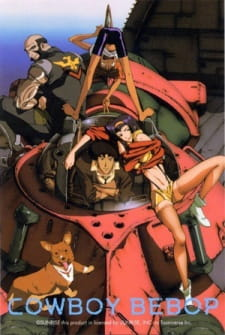

In [ ]:
import requests
from IPython.display import Image, display

url = raw_animeDF["Image URL"].iloc[0]
response = requests.get(url)
display(Image(response.content))

While it may be interesting to use this column, it goes beyond the scope of our initial proposal and would require further analysis as to the kind of model that could be leveraged to better recommend anime based on these images.

### User Details DF

Column sections:
* **Index**: Mal ID, Username
* **Short text**: Gender, Birthday, Location, Joined
* **Numeric**: Mean Score, Days Watched, Watching, Completed, On Hold, Dropped, Plan to Watch, Total Entries, Rewatched, Episodes Watched

Crucial columns that, should the row not have this data, we should drop the entire row
* Mal ID

In [ ]:
# Reordering based on new column sections
userDetailsDF = userDetailsDF[[
    "Mal ID", "Username",
    "Gender", "Birthday", "Location", "Joined",
    "Mean Score", "Days Watched", "Watching", "Completed", "On Hold", "Dropped", "Plan to Watch", "Total Entries", "Rewatched", "Episodes Watched"
]]
userDetailsDF.head(2)

,Mal ID,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
0,1,Xinil,Male,1985-03-04T00:00:00+00:00,California,2004-11-05T00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
1,3,Aokaado,Male,NaN,"Oslo, Norway",2004-11-11T00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


In [ ]:
display(userDetailsDF.shape[0] == userDetailsDF.dropna().shape[0])
# Null values have not been dealt with. Let us investigate further

display(userDetailsDF.shape[0])
userDetailsDF.dropna().shape[0]
# That's over 500,000 rows dropped. This will definitely need some detailed analysis

False

731290

115457

In [ ]:
userDetailsDF.dropna(how="any").shape

(115457, 16)

Over 550,000 rows have at least one null value. From our column-by-column analysis in the sections below, it is likely that they are missing Gender, Location, and/or Birthday values. As discussed in more detail later on, we concluded the following for each column:

* Gender: we will keep this data, since we have over 200,000 known values; we will only use these rows for gender-specific analyses.
* Birthday: we will keep this data, but heavily depend on the "Joined" column as a cross-comparison for both new users and as a proxy for age.
* Location: while there are over 120,000 known locations, they are not very clean and will require a concerted effort to clean – since there is no uniformity in the type of location provided, nor the confirmation of their existence.

The remaining numerical all have plausible values, and thus will be useful in our analysis.

In [ ]:
# Creating copy of dataset
clean_userDetailsDF = userDetailsDF.copy()

# Since Mal IDs are unique, we can set that to the index
clean_userDetailsDF = clean_userDetailsDF.set_index(keys="Mal ID").sort_index()
display(clean_userDetailsDF.shape) # new DF shape

# Converting Birthday to datetime object
clean_userDetailsDF.Birthday = pd.to_datetime(clean_userDetailsDF.Joined, format="mixed")

# Dropping Location
clean_userDetailsDF.drop(columns=["Location"],inplace=True)

# Converting Joined to datetime objects
clean_userDetailsDF.Joined = pd.to_datetime(clean_userDetailsDF.Joined, format="mixed")

clean_userDetailsDF.head(2)

(731290, 15)

,Username,Gender,Birthday,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,
1,Xinil,Male,2004-11-05 00:00:00+00:00,2004-11-05 00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
3,Aokaado,Male,2004-11-11 00:00:00+00:00,2004-11-11 00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


In [ ]:
# Saving new clean data as CSV
clean_userDetailsDF.to_csv(clean_data_folder + "clean_user_details_data.csv")

Similar to the first dataset, we will investigate the extent of Uddin's initial data cleaning in the sections below (which will explain why there are gaps in the Mal ID column)

##### Mal ID

In [ ]:
# Checking if Mal ID is unique
userDetailsDF["Mal ID"].nunique() == userDetailsDF.shape[0]

True

In [ ]:
# Since Mal IDs are unique, we can set that to the index
userDetailsDF = userDetailsDF.set_index(keys="Mal ID").sort_index()
display(userDetailsDF.shape) # new DF shape
userDetailsDF.head(2)

(731290, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
1,Xinil,Male,1985-03-04T00:00:00+00:00,California,2004-11-05T00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
3,Aokaado,Male,NaN,"Oslo, Norway",2004-11-11T00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


##### Username

In [ ]:
# Checking if Username is unique
display(userDetailsDF.Username.nunique() == userDetailsDF.shape[0])

# Investigating repeated users
display(userDetailsDF.Username.nunique())
userDetailsDF.shape[0]

False

731289

731290

In [ ]:
# The values differ by one value – it might be null
display(userDetailsDF[userDetailsDF["Username"].isna()])

# This line should confirm it
display(userDetailsDF.Username.nunique(dropna=False) == userDetailsDF.shape[0])

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
20930,NaN,NaN,NaN,NaN,2007-11-09T00:00:00+00:00,7.59,58.8,8.0,236.0,8.0,3.0,17.0,272.0,14.0,3447.0


True

There are unique usernames, so we can leave this column as is.

#### Short text

##### Gender

In [ ]:
userDetailsDF.Gender.value_counts(dropna=False)

,count
Gender,
NaN,506907
Male,126984
Female,96485
Non-Binary,914


Over 500,000 null values. While just over 200,000 are known, we will be missing over 50% of the data. We will strongly consider dropping this column – unless we want gender-specific analyses, in which case, we would need to filter for the users that specified their genders

##### Birthday

In [ ]:
userDetailsDF.Birthday.value_counts(dropna=False)

,count
Birthday,
NaN,563222
1990-01-01T00:00:00+00:00,177
1989-03-26T00:00:00+00:00,169
1980-01-01T00:00:00+00:00,166
1930-01-01T00:00:00+00:00,153
...,...
2001-06-08T00:00:00+00:00,1
2010-03-04T00:00:00+00:00,1
2008-05-06T00:00:00+00:00,1


Over 550,000 null values. While over 150,000 birthdays are known, we will be missing 50% of the data. We will strongly consider dropping this column - again, unless we want analyses specific to this column, such as age demographics.

In [ ]:
# Converting to datetime object
userDetailsDF.Birthday = pd.to_datetime(userDetailsDF.Joined, format="mixed")
userDetailsDF.head(2)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
1,Xinil,Male,2004-11-05 00:00:00+00:00,California,2004-11-05T00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
3,Aokaado,Male,2004-11-11 00:00:00+00:00,"Oslo, Norway",2004-11-11T00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


##### Location

In [ ]:
userDetailsDF.Location.value_counts(dropna=False)

,count
Location,
NaN,578485
Poland,2458
Germany,1706
Canada,1693
California,1506
...,...
G-ce,1
Karakura town.,1
~~~~~,1


Over 570,000 null values. While over 120,000 locations are known, they are not very clean. Just from the initial display, there are mentions of countries, while others have states, or a mix of cities and states, etc.

There are also some unique locations, such as "On the computer in Outer Space, Asia," that even if true, are not specific enough to provide a useful Earth-bound geographic association when doing analyses later on in the project. The remaining locations, such as "in a place with me" and "Killing Neko_Neji," are evidently the result of self-assigned location data without the use of drop-down menus or some other specific entry system.

While our analysis may benefit from user locations, this limitation strongly suggests dropping the column altogether (unless a longer effort is sacrificed cleaning up the dataset).

##### Joined

In [ ]:
userDetailsDF.Joined.value_counts(dropna=False)

,count
Joined,
2011-11-09T00:00:00+00:00,3892
2011-11-21T00:00:00+00:00,3828
2011-11-22T00:00:00+00:00,3798
2011-11-08T00:00:00+00:00,3674
2011-11-17T00:00:00+00:00,3563
...,...
2005-09-16T00:00:00+00:00,1
2005-10-18T00:00:00+00:00,1
2005-10-25T00:00:00+00:00,1


In [ ]:
# Investigating the number of null values in this column
userDetailsDF.Joined.isna().sum()

np.int64(0)

This column does not have any null values. As such, we can confidently use it, and potentially use it as a proxy for age. Additionally, we can use the dataset to estimate the average age for users joining the MAL platform, and potentially starting to watch anime (in addition to potential external research comparison).

In [ ]:
# Converting to datetime objects
userDetailsDF.Joined = pd.to_datetime(userDetailsDF.Joined, format="mixed")
userDetailsDF.head(2)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
1,Xinil,Male,2004-11-05 00:00:00+00:00,California,2004-11-05 00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
3,Aokaado,Male,2004-11-11 00:00:00+00:00,"Oslo, Norway",2004-11-11 00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


#### Numerical

##### Mean Score

In [ ]:
userDetailsDF["Mean Score"].value_counts(dropna=False)

,count
Mean Score,
0.00,376196
10.00,24905
9.00,15803
8.00,12942
8.50,5684
...,...
3.84,1
255.00,1
1.75,1


In [ ]:
display(userDetailsDF[userDetailsDF["Mean Score"].isna()].shape)
userDetailsDF[userDetailsDF["Mean Score"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Only missing 8 rows of data. While we can confidently drop these rows, we chose not to since we also desired to provide recommendations to new users (without any "Mean Score" to reference). These users will be a good proxy for new users, since they also do not have any other data in the remaining numerical columns. In practice, however, it should be noted that, by the time users have found then joined the MAL community, they have likely already encountered anime and will likely have their own (albeit, limited) preferences on anime.

##### Days Watched

In [ ]:
# Checking most and least popular values
userDetailsDF["Days Watched"].value_counts(dropna=False)

,count
Days Watched,
0.0,356112
0.4,5675
0.2,5334
0.1,4228
0.6,2770
...,...
383.8,1
558.0,1
459.6,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Days Watched"].isna()].shape)
userDetailsDF[userDetailsDF["Days Watched"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous column's analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Watching

In [ ]:
# Checking most and least popular values
userDetailsDF["Watching"].value_counts(dropna=False)

,count
Watching,
0.0,406513
1.0,61276
2.0,41558
3.0,32552
4.0,26306
...,...
1187.0,1
350.0,1
661.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Watching"].isna()].shape)
userDetailsDF[userDetailsDF["Watching"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Completed

In [ ]:
# Checking most and least popular values
userDetailsDF.Completed.value_counts(dropna=False)

,count
Completed,
0.0,369391
1.0,22098
2.0,12573
3.0,9550
4.0,8270
...,...
3979.0,1
3528.0,1
2177.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF.Completed.isna()].shape)
userDetailsDF[userDetailsDF.Completed.isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### On Hold

In [ ]:
# Checking most and least popular values
userDetailsDF["On Hold"].value_counts(dropna=False)

,count
On Hold,
0.0,531300
1.0,39814
2.0,24903
3.0,18027
4.0,14128
...,...
1685.0,1
508.0,1
642.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["On Hold"].isna()].shape)
userDetailsDF[userDetailsDF["On Hold"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Dropped

In [ ]:
# Checking most and least popular values
userDetailsDF.Dropped.value_counts(dropna=False)

,count
Dropped,
0.0,539661
1.0,35417
2.0,21957
3.0,15790
4.0,12176
...,...
776.0,1
567.0,1
2417.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF.Dropped.isna()].shape)
userDetailsDF[userDetailsDF.Dropped.isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Plan to Watch

In [ ]:
# Checking most and least popular values
userDetailsDF["Plan to Watch"].value_counts(dropna=False)

,count
Plan to Watch,
0.0,472247
1.0,31728
2.0,18376
3.0,13353
4.0,10968
...,...
4952.0,1
1610.0,1
1949.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Plan to Watch"].isna()].shape)
userDetailsDF[userDetailsDF["Plan to Watch"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Total Entries

In [ ]:
# Checking most and least popular values
userDetailsDF["Total Entries"].value_counts(dropna=False)

,count
Total Entries,
0.0,340242
1.0,28089
2.0,13285
3.0,9518
4.0,8058
...,...
3017.0,1
2655.0,1
5323.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Total Entries"].isna()].shape)
userDetailsDF[userDetailsDF["Total Entries"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Rewatched

In [ ]:
# Checking most and least popular values
userDetailsDF["Rewatched"].value_counts(dropna=False)

,count
Rewatched,
0.0,590483
2.0,16284
1.0,15046
3.0,11339
4.0,8343
...,...
709.0,1
506.0,1
512.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Rewatched"].isna()].shape)
userDetailsDF[userDetailsDF["Rewatched"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

##### Episodes Watched

In [ ]:
# Checking most and least popular values
userDetailsDF["Episodes Watched"].value_counts(dropna=False)

,count
Episodes Watched,
0.0,352107
1.0,2960
26.0,2130
13.0,1531
24.0,1523
...,...
10718.0,1
17480.0,1
19056.0,1


In [ ]:
# Confirming the details of existing null values
display(userDetailsDF[userDetailsDF["Episodes Watched"].isna()].shape)
userDetailsDF[userDetailsDF["Episodes Watched"].isna()]

(8, 15)

,Username,Gender,Birthday,Location,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
Mal ID,,,,,,,,,,,,,,,
8682,DeleteMe3409,Female,2007-07-27 00:00:00+00:00,NaN,2007-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79090,rosycrystals,Female,2008-07-23 00:00:00+00:00,Kansas,2008-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125668,BlazingDevil,Male,2008-12-20 00:00:00+00:00,Kamloops British Columbia in Canada,2008-12-20 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160113,FuckedUpProfile,Female,2009-03-17 00:00:00+00:00,Organisation 13,2009-03-17 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231825,Account_Closed,Female,2009-09-08 00:00:00+00:00,"Portersville, Pennsylvania",2009-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232646,-Lovely-,Female,2009-09-10 00:00:00+00:00,"Portersville,Pennsylvania",2009-09-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277237,sarah_sweet,Female,2010-01-02 00:00:00+00:00,Romania,2010-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561555,RaisinMuffins,Male,2011-08-31 00:00:00+00:00,NaN,2011-08-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It seems that the same 8 rows of data from the previous columns' analysis are the only rows missing data in this column. Again, we will keep the column intact, and leave these rows as well.

### User Score DF

Column sections:
* **Index:**, user_id, anime_id
* **Text:** Username, Anime Title
* **Numerical:** rating

In [ ]:
# Rerranging columns to columns sections indicated above
userScoreDF = userScoreDF[[
    "user_id", "anime_id",
    "Username", "Anime Title",
    "rating"
]]
userScoreDF.head(2)

,user_id,anime_id,Username,Anime Title,rating
0,1,21,Xinil,One Piece,9
1,1,48,Xinil,.hack//Sign,7


In [ ]:
userScoreDF.isna().sum()

,0
user_id,0
anime_id,0
Username,232
Anime Title,0
rating,0


Only 232 null values in the data set. We can check for other types of nulls, based on the convention from the previous datasets.

In [ ]:
userScoreDF.replace(to_replace=["UNKNOWN", "Unknown", "", "Not avalailable", None], value = np.nan).isna().sum()

,0
user_id,0
anime_id,0
Username,444
Anime Title,0
rating,0


Only 212 more null values.

Following our detailed investigation below, we concluded that while it is not ideal to have the null values in the Username column, it is the only column with missing data (even considering the "UNKNOWN" and other similar values convention used in the other two datasets). As such, we opted to keep the data is.

Having said that, in the **Index** section, we discovered some potentially concerning statistics regarding matching users and anime across all three datasets. While our domain knowledge confirms some viable reasons as to the mismatch, we opted to keep this dataset as is, but proceeding with caution.


In [ ]:
# Saving new clean data as CSV
userScoreDF.to_csv(clean_data_folder + "clean_user_details_data.csv")

Similar to the two previous datasets, we detailed our column-by-column analysis in the sections below.

#### Index

It wouldn't make sense to have any either index columns as unique, since it's the combination of both that we care about being unique.

In [ ]:
# Checking if anime_id is indeed unique (i.e. matches number of item in dataframe)
userScoreDF.groupby(["user_id", "anime_id"]).value_counts(dropna=False)

user_id  anime_id  Username    Anime Title                                                rating
1        1         Xinil       Cowboy Bebop                                               10        1
         5         Xinil       Cowboy Bebop: Tengoku no Tobira                            8         1
         6         Xinil       Trigun                                                     10        1
         7         Xinil       Witch Hunter Robin                                         9         1
         8         Xinil       Bouken Ou Beet                                             6         1
                                                                                                   ..
1291087  32935     Oblongata   Haikyuu!! Karasuno Koukou vs. Shiratorizawa Gakuen Koukou  10        1
         32995     Oblongata   Yuri!!! on Ice                                             8         1
1291097  226       JuunanaSai  Elfen Lied                                              

In [ ]:
userScoreDF.shape

(24325191, 5)

In [ ]:
# Showing the difference: the number of duplicated combinations
userScoreDF.shape[0] - len(userScoreDF.groupby(["user_id", "anime_id"]).value_counts())

232

Since it's such a small minority, we can leave them in there. Now, we'll test whether or not there are the same number of unique anime_id values, as well as user_id values, across all three datasets.

In [ ]:
print("Unique anime in animeDF:", raw_animeDF.anime_id.nunique())
print("Unique anime in userScoreDF:", userScoreDF.anime_id.nunique())

print("\nUnique users in userDetailsDF:", userDetailsDF.Username.nunique())
print("Unique users in userScoreDF:", userScoreDF.user_id.nunique())

Unique anime in animeDF: 24905
Unique anime in userScoreDF: 16500

Unique users in userDetailsDF: 731289
Unique users in userScoreDF: 270033


This tells us that we have just over 9,000 unseen anime by our userbase, and about 350,000.

From our domain knowledge, this can be as a result of Uddiq's choice of threshold for the anime and users – for example, only anime with over 1,000 ratings, or users that have written 5 comments on any community page – but he has not detailed his data collection methods. Another factor could be differing criteria for each of the datasets, creating what seems like an excessive number of cold cases.

Having said that, the code below remove any further concern for missing data, since we were able to more directly confirm whether users and anime from both datasets had enough matching values. A similar code block is repeated in the Data Preparation & Implementation section to create boolean columns on whether matching meta data can be found on any given anime-user combination, and hence can be used in creating the plurality of subsetted DataFrames for our model set.

In [ ]:
# Creating flags showing whether each rating has matching metadata
anime_ids_with_metadata = set(raw_animeDF["anime_id"])
user_ids_with_metadata = set(userDetailsDF["Username"])

testDF = userScoreDF.copy()

testDF["has_anime_metadata"] = testDF["anime_id"].isin(anime_ids_with_metadata)
testDF["has_user_metadata"] = testDF["Username"].isin(user_ids_with_metadata)
testDF["has_username"] = testDF["Username"].notna()

display(testDF.head())

testDF[[
    "has_anime_metadata",
    "has_user_metadata",
    "has_username"
]].mean() * 100

,user_id,Username,anime_id,Anime Title,rating,has_anime_metadata,has_user_metadata,has_username
0,1,Xinil,21,One Piece,9,True,True,True
1,1,Xinil,48,.hack//Sign,7,True,True,True
2,1,Xinil,320,A Kite,5,True,True,True
3,1,Xinil,49,Aa! Megami-sama!,8,True,True,True
4,1,Xinil,304,Aa! Megami-sama! Movie,8,True,True,True


has_anime_metadata    99.997772
has_user_metadata     97.856494
has_username          99.999046
dtype: float64

#### Text

##### Username

In [ ]:
userScoreDF.Username.value_counts(dropna=False).head(50)

The fact that there aren't an equal number of usernames indicates that there are indeed "cold cases" that can be used in the dataset.

In [ ]:
userScoreDF.shape

In [ ]:
nullDF1 = userScoreDF[userScoreDF.Username.isna()]
nullDF2 = userScoreDF[userScoreDF.Username.replace(to_replace=["UNKNOWN", "Unknown", "", "Not avalailable", None], value = np.nan).isna()]

display(nullDF1.shape)
display(nullDF1)
display(nullDF2.shape)
nullDF2

We also saw a number of null values in this column in the initial review.

While it's not ideal, it i not unmanageable. We just need to consider how to navigate those values. It seems that only Username is missing data, but there accompanying user_id values are there, which is the most important identifier.

The Username column can be an additional user validation column throughout the project, but user_id will be the primary key when making joined datasets for the models.

##### Anime Title

In [ ]:
userScoreDF["Anime Title"].value_counts(dropna=False)

We can see some obvious cases of the most popular anime (e.g. Naruto and Bleach). We'll need to implement methods to give lower weights to these anime, both based on their ranks, also potentially based on the popularity within this dataset alone.

We'll still need to confirm if there are any missing values following the ```.replace()``` function from before.

In [ ]:
nullDF1 = userScoreDF[userScoreDF["Anime Title"].isna()]
nullDF2 = userScoreDF[userScoreDF["Anime Title"].replace(to_replace=["UNKNOWN", "Unknown", "", "Not avalailable", None], value = np.nan).isna()]

display(nullDF1.shape)
display(nullDF1)
display(nullDF2.shape)
nullDF2

Confirmed! This has no obvious missing values. We can leave this column as is.

#### Numerical
##### rating

In [ ]:
userScoreDF.rating.value_counts(dropna=False)

This column is fine. We can leave it as it is.

# 3. Exploratory Data Analysis
---

The analysis should be guided by the problem defined earlier. Show your code and explain the process and results.

- Exploratory Analysis:
    * Use visualizations and summary statistics to understand the data.
    * Include plots such as histograms, scatter plots, box plots, correlation matrices, etc.
    * Explain key trends and relationships observed in the data.
- Insights: Provide interpretations of patterns, distributions, and anomalies in the data.
- Feature Engineering and Selection:
    * Extract or construct new features relevant to the problem.
    * Highlight the features that will be used in your model and justify their selection (e.g., based on correlation or domain knowledge).


The goal of this project to understand which characteristic of anime associated with ratings,popularity and higher user.Exploratory Data Analysis purpose to identify important features that may be useful for predective modeling

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive'))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
raw_data_folder = "/content/drive/MyDrive/INFO 371 Project/Raw Data/"

import pandas as pd

animeDF = pd.read_csv(raw_data_folder + "anime-dataset-2023.csv")

animeDF.shape

(24905, 24)

In [ ]:
animeDF.shape
animeDF.info()
animeDF.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   anime_id      24905 non-null  int64 
 1   Name          24905 non-null  object
 2   English name  24905 non-null  object
 3   Other name    24905 non-null  object
 4   Score         24905 non-null  object
 5   Genres        24905 non-null  object
 6   Synopsis      24905 non-null  object
 7   Type          24905 non-null  object
 8   Episodes      24905 non-null  object
 9   Aired         24905 non-null  object
 10  Premiered     24905 non-null  object
 11  Status        24905 non-null  object
 12  Producers     24905 non-null  object
 13  Licensors     24905 non-null  object
 14  Studios       24905 non-null  object
 15  Source        24905 non-null  object
 16  Duration      24905 non-null  object
 17  Rating        24905 non-null  object
 18  Rank          24905 non-null  object
 19  Popu

,anime_id,Popularity,Favorites,Members
count,24905.000000,24905.000000,24905.000000,2.490500e+04
mean,29776.709014,12265.388356,432.595222,3.710496e+04
std,17976.076290,7187.428393,4353.181647,1.568252e+05
min,1.000000,0.000000,0.000000,0.000000e+00
25%,10507.000000,6040.000000,0.000000,2.090000e+02
50%,34628.000000,12265.000000,1.000000,1.056000e+03
75%,45240.000000,18491.000000,18.000000,9.326000e+03
max,55735.000000,24723.000000,217606.000000,3.744541e+06


**Data Overview**
This Dataset contains 24,905 titles of anime and 24 variables that describes anime characteristics. The goal of the explarotary analysis is to identify features that influence popularity and ratings

In [ ]:
animeDF['Score'].dtype
animeDF['Score'].value_counts().head(20)
animeDF['Score'].isna().sum()

np.int64(0)

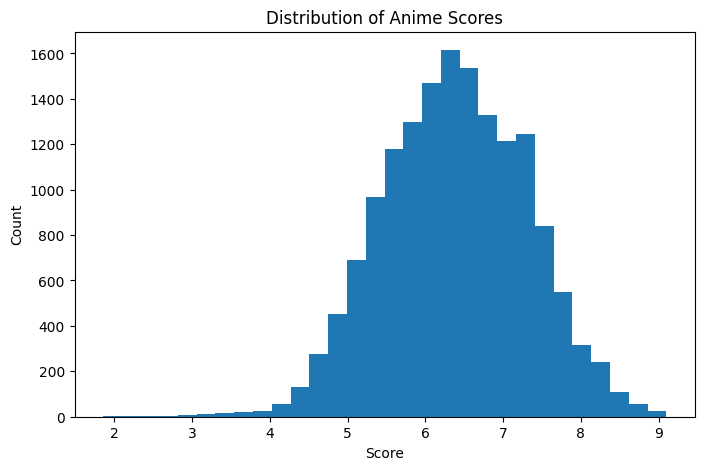

In [ ]:
animeDF['Score'] = pd.to_numeric(animeDF['Score'], errors='coerce')

scores = animeDF['Score'].dropna()

plt.figure(figsize=(8,5))
plt.hist(scores, bins=30)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

In [ ]:
animeDF['Score'].dtype
animeDF['Score'].value_counts().head(10)

,count
Score,
6.31,80
6.54,80
6.51,79
6.25,79
6.52,78
6.50,76
6.36,75
6.32,74
5.99,74


**Distrubution of Anime Scores.**
Anime rating receiving ratings between 5 and 8.The highest concentration occurs around 6 and 7 points.Low ratings(that is below 4) and high ratings (above 8.5) are uncommon.Moreover,this suggests that the majority of anime receive moderate to favourable ratings from users. The distribution is fairly balanced. This indicates that the dataset does not suffer from severe rating bias. Rating bias is towards extremely high or low scores.

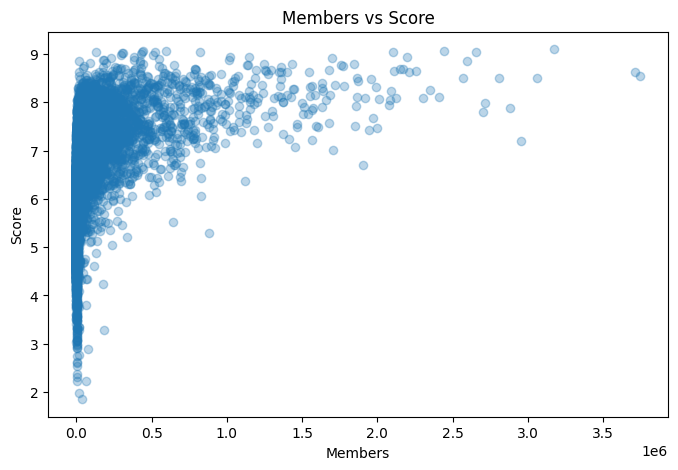

In [ ]:
#Ratings and popularity
plt.figure(figsize=(8,5))

plt.scatter(
    animeDF['Members'],
    animeDF['Score'],
    alpha=0.3
)

plt.title('Members vs Score')
plt.xlabel('Members')
plt.ylabel('Score')

plt.show()

The scatter plot shows how the number of members compares with anime scores. Most anime are concentrated on the left-hand side of the graph, indicating that they have fewer members. Anime with more members generally have scores above 7, while anime with fewer members show a wider range of scores. This suggests that popular anime tend to receive higher ratings, although the correlation is not very strong

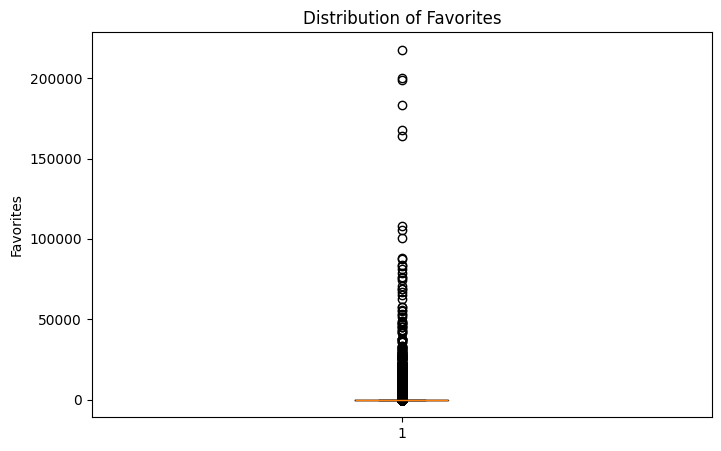

In [ ]:
#Favorite distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(animeDF['Favorites'])

plt.title('Distribution of Favorites')
plt.ylabel('Favorites')

plt.show()

The distribution of favourites is heavily skewed. While most anime have a small number of favourites, a small number of anime have an extremely high number of favourites. This indicates that user engagement is concentrated among a few very popular titles.

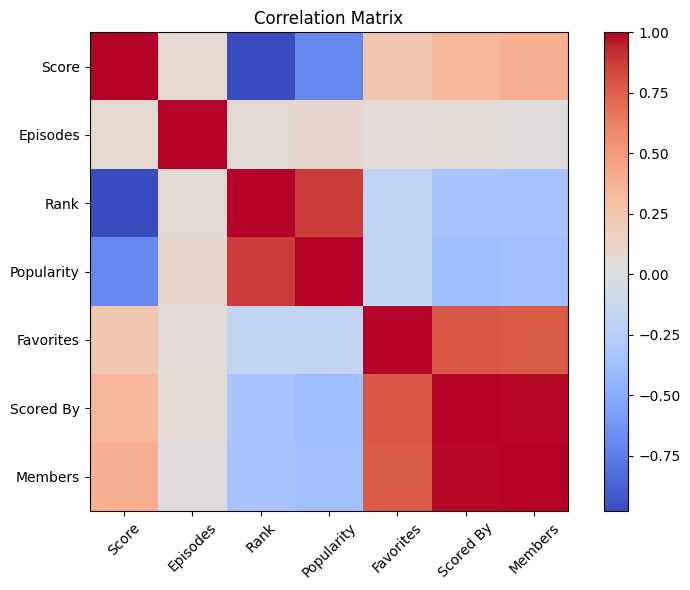

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = [
    'Score',
    'Episodes',
    'Rank',
    'Popularity',
    'Favorites',
    'Scored By',
    'Members'
]

for col in numeric_cols:
    animeDF[col] = pd.to_numeric(animeDF[col], errors='coerce')

corr = animeDF[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals several important relationships between anime characteristics, including those relating to genre, popularity and other key aspects of the medium. The strongest positive correlations are observed between 'Members', 'Scored By' and 'Favorites', indicating that anime with larger audiences tend to receive more ratings and favorites. There is a moderate positive relationship between Score and popularity-related variables, which suggests that users tend to be more popular if they rate anime higher.

It is to be expected that there is a strong negative correlation between rank and score, since lower rank values are associated with higher-ranked anime. The number of episodes appears to be weakly correlated with most other variables, suggesting that anime length does not strongly influence ratings or popularity.

In [ ]:
animeDF['Genre_Count'] = animeDF['Genres'].apply(
    lambda x: len(str(x).split(','))
)
import numpy as np

animeDF['Log_Members'] = np.log1p(animeDF['Members'])
animeDF['Log_Favorites'] = np.log1p(animeDF['Favorites'])

# 4. Model Building and Evaluation
---
- Model Selection: Describe the machine learning or data mining techniques used (e.g., regression, classification, clustering, association rules, etc.) and justify your choice.

- Model Implementation: Present and explain the code for implementing the chosen models.
  * Describe the architecture of your solution (e.g., train-test split, cross-validation, data pipelines).
  * Discuss any hyperparameter tuning strategies (e.g., grid search) and the range of parameters explored.

- Model Evaluation:
  * Define the metrics used to evaluate the model's performance.
  * Compare the results of different models and approaches
  * Use tables or plots (e.g., confusion matrix, precision-recall curves, ROC curves, or feature importance plots) to illustrate performance.
  * Report training vs. testing performance to highlight potential overfitting or underfitting issues.
- Model Interpretation:
  * Explain the results of the model in the context of your original problem or question.
  * Identify which features contributed most to the model's predictions and provide explanations.


## Model Selection

We implement five recommendation approaches:

1. **Item-based collaborative filtering recommender using K-nearest neighbors and cosine similarity.** This model identifies patterns in user rating behavior and recommends anime based on similarities between users or items. Collaborative filtering is especially useful when there is enough user interaction data to detect preference patterns.

2. **Content-based recommender using TF-IDF features** from anime metadata such as genres, synopsis, type, source, and rating. This model recommends anime based on shared characteristics such as genre, type, synopsis, score, and popularity-related features. Content-based filtering is useful when a user has limited history or when an anime title has few ratings.

3. **Matrix factorization through TruncatedSVD.** This approach learns latent user and anime factors from the user-item rating matrix and recommends anime with high predicted scores for each user. These latent factors could result in type-casting such as discovering anime with underlying genre-combination tropes (e.g. Adventure stories tied with Romance tropes), or finding users with similar overly critical ratings of anime overall despite high "Rewatched" anime statistics.

4. **Hybrid recommender** that combines collaborative filtering, content-based filtering, and matrix factorization scores. This allows the system to use both user-rating behavior and anime metadata, hence, combining the strengths of all three methods and helps reduce the weaknesses of each individual model

5. **K-Means user-segment recommender.** Users are clustered based on viewing behavior such as mean score, days watched, completed anime, dropped anime, and total entries. The model then recommends anime that are highly rated by users in the same cluster.

This model set reflects several topics, including K-nearest neighbors, text representation/text mining, unsupervised learning, K-Means clustering, and evaluation of machine-learning-based data mining applications.

## Data Preparation & Model Implementation

In [ ]:
import numpy as np
import pandas as pd


# Re-loading data
clean_animeDF = pd.read_csv("Clean Data/clean_anime_data.csv")
clean_userDetailsDF = pd.read_csv("Clean Data/clean_user_details_data.csv")
clean_userScoreDF = pd.read_csv("Clean Data/clean_user_score_data.csv").drop(columns=["Unnamed: 0"])

# Re-doing datetime transformations
clean_animeDF["Aired Date"] = pd.to_datetime(clean_animeDF["Aired Date"], format="mixed")
clean_animeDF["Last Episode Date"] = pd.to_datetime(clean_animeDF["Last Episode Date"], format="mixed")

clean_userDetailsDF.Birthday = pd.to_datetime(clean_userDetailsDF.Joined, format="mixed")
clean_userDetailsDF.Joined = pd.to_datetime(clean_userDetailsDF.Joined, format="mixed")

# Displaying
display(clean_animeDF.shape)
display(clean_animeDF.head(2))

display(clean_userDetailsDF.shape)
display(clean_userDetailsDF.head(2))

display(clean_userScoreDF.shape)
clean_userScoreDF.head(2)

(19997, 23)

,anime_id,Name,English name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,...,Source,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members
0,1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,Spring,Finished Airing,...,Original,R - 17+ (violence & profanity),8.75,26.0,24.0,41.0,43,78525,914193.0,1771505
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,...,Original,R - 17+ (violence & profanity),8.38,1.0,115.0,189.0,602,1448,206248.0,360978


(731290, 15)

,Mal ID,Username,Gender,Birthday,Joined,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
0,1,Xinil,Male,2004-11-05 00:00:00+00:00,2004-11-05 00:00:00+00:00,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
1,3,Aokaado,Male,2004-11-11 00:00:00+00:00,2004-11-11 00:00:00+00:00,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0


(24325191, 5)

,user_id,anime_id,Username,Anime Title,rating
0,1,21,Xinil,One Piece,9
1,1,48,Xinil,.hack//Sign,7


In [ ]:
# Preparing model-ready copies
anime_meta = clean_animeDF.copy()
user_meta = clean_userDetailsDF.copy()
ratings_all = clean_userScoreDF.copy()

# Rename user metadata ID for easier merging later
user_meta = user_meta.rename(columns={"Mal ID": "user_id"})

In [ ]:
# Creating flags showing whether each rating has matching metadata
anime_ids_with_metadata = set(anime_meta["anime_id"])
user_ids_with_metadata = set(user_meta["user_id"])

ratings_all["has_anime_metadata"] = ratings_all["anime_id"].isin(anime_ids_with_metadata)
ratings_all["has_user_metadata"] = ratings_all["user_id"].isin(user_ids_with_metadata)
ratings_all["has_username"] = ratings_all["Username"].notna()

ratings_all[[
    "has_anime_metadata",
    "has_user_metadata",
    "has_username"
]].mean() * 100

has_anime_metadata    99.650535
has_user_metadata     97.856494
has_username          99.999046
dtype: float64

Because our datasets still contain differing amounts of missing values, we opted to use **model-specific filtering** to run each separate model. As such, each model requires it's own separate preparation steps.

In [ ]:
# Importing all necessary modules and functions for models
## Collaborative Filtering
from scipy.sparse import csr_matrix

## Content-Based Filtering
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Matrix Factorization
from sklearn.decomposition import TruncatedSVD

## K-Means User-Segmentation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### Collaborative Filtering: anime-based KNN recommender

In [ ]:
# Function for filtering only for computational feasibility
def filter_for_collaborative_filtering(ratings, min_user_ratings=20, min_anime_ratings=50):
    """
    Creates a smaller but still meaningful ratings subset for collaborative filtering.
    """
    user_counts = ratings["user_id"].value_counts()
    anime_counts = ratings["anime_id"].value_counts()

    active_users = user_counts[user_counts >= min_user_ratings].index
    rated_anime = anime_counts[anime_counts >= min_anime_ratings].index

    cf_ratings = ratings[
        ratings["user_id"].isin(active_users)
        & ratings["anime_id"].isin(rated_anime)
    ].copy()

    return cf_ratings

In [ ]:
cf_ratings = filter_for_collaborative_filtering(
    ratings_all,
    min_user_ratings=20,
    min_anime_ratings=50
)

display(ratings_all.shape)
display(cf_ratings.shape)

(24325191, 8)

(23547259, 8)

In [ ]:
cf_ratings.head(2)

,user_id,anime_id,Username,Anime Title,rating,has_anime_metadata,has_user_metadata,has_username
0,1,21,Xinil,One Piece,9,True,True,True
1,1,48,Xinil,.hack//Sign,7,True,True,True


In [ ]:
# Function for building a sparse user-item matrix
def build_sparse_user_item_matrix(ratings):
    user_ids = ratings["user_id"].unique()
    anime_ids = ratings["anime_id"].unique()

    user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
    anime_to_idx = {anime_id: idx for idx, anime_id in enumerate(anime_ids)}

    row_idx = ratings["user_id"].map(user_to_idx)
    col_idx = ratings["anime_id"].map(anime_to_idx)

    matrix = csr_matrix(
        (ratings["rating"], (row_idx, col_idx)),
        shape=(len(user_ids), len(anime_ids))
    )

    idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
    idx_to_anime = {idx: anime_id for anime_id, idx in anime_to_idx.items()}

    return matrix, user_to_idx, anime_to_idx, idx_to_user, idx_to_anime

In [ ]:
user_item_matrix, user_to_idx, anime_to_idx, idx_to_user, idx_to_anime = (
    build_sparse_user_item_matrix(cf_ratings)
)

user_item_matrix.shape

(164008, 9239)

In [ ]:
user_item_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 23547259 stored elements and shape (164008, 9239)>

In [ ]:
# Helper function for readable recommendations
def add_anime_info(recs, anime_meta):
    """
    Adds anime title and metadata to recommendation outputs.
    """
    info_cols = [
        "anime_id", "Name", "English name", "Genres", "Type",
        "Score", "Episodes", "Popularity", "Members"
    ]

    available_cols = [col for col in info_cols if col in anime_meta.columns]

    return (
        recs.merge(anime_meta[available_cols], on="anime_id", how="left")
            .sort_values("recommendation_score", ascending=False)
    )

In [ ]:
# Item-based KNN recommender
def item_based_knn_recommender(
    user_id,
    ratings,
    anime_meta,
    user_item_matrix,
    user_to_idx,
    anime_to_idx,
    idx_to_anime,
    top_n=10,
    n_neighbors=20,
    max_seen_items=30
):
    """
    Item-based collaborative filtering using KNN/cosine similarity.
    Recommends anime similar to the anime a user has already rated highly.

    Default top_n = 10 and max_seen_items = 30 are used for faster processing
    due to large data size.
    """
    if user_id not in user_to_idx:
        raise ValueError("User not found in collaborative-filtering subset.")

    # Anime x users matrix
    item_user_matrix = user_item_matrix.T

    knn = NearestNeighbors(
        metric="cosine",
        algorithm="brute",
        n_neighbors=n_neighbors + 1
    )

    knn.fit(item_user_matrix)

    user_seen = ratings[ratings["user_id"] == user_id][["anime_id", "rating"]]
    user_seen = user_seen[user_seen["anime_id"].isin(anime_to_idx)]

    # Using highest-rated seen anime to reduce runtime
    user_seen = user_seen.sort_values("rating", ascending=False).head(max_seen_items)

    scores = {}

    for i, row in user_seen.iterrows():
        anime_id = row["anime_id"]
        rating = row["rating"]
        anime_idx = anime_to_idx[anime_id]

        distances, indices = knn.kneighbors(
            item_user_matrix[anime_idx],
            n_neighbors=n_neighbors + 1
        )

        for distance, neighbor_idx in zip(distances.flatten(), indices.flatten()):
            neighbor_anime_id = idx_to_anime[neighbor_idx]

            if neighbor_anime_id == anime_id:
                continue

            similarity = 1 - distance
            scores[neighbor_anime_id] = scores.get(neighbor_anime_id, 0) + similarity * rating

    # Removing anime already rated by the user
    seen_ids = set(user_seen["anime_id"])
    for aid in seen_ids:
        scores.pop(aid, None)

    recommendations = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    recommendations.columns = ["anime_id", "recommendation_score"]

    return add_anime_info(recommendations, anime_meta)

In [ ]:
# Example recommendation on single user
sample_user = cf_ratings["user_id"].iloc[0]
display(sample_user)

item_based_knn_recommender(
    user_id=sample_user,
    ratings=cf_ratings,
    anime_meta=anime_meta,
    user_item_matrix=user_item_matrix,
    user_to_idx=user_to_idx,
    anime_to_idx=anime_to_idx,
    idx_to_anime=idx_to_anime,
    top_n=10
)

1

,anime_id,recommendation_score,Name,English name,Genres,Type,Score,Episodes,Popularity,Members
0,1535,90.582415,Death Note,Death Note,"Supernatural, Suspense",TV,8.62,37.0,2,3713315
1,1575,77.724122,Code Geass: Hangyaku no Lelouch,Code Geass: Lelouch of the Rebellion,"Action, Award Winning, Drama, Sci-Fi",TV,8.70,25.0,21,2151722
2,226,67.996610,Elfen Lied,Elfen Lied,"Action, Drama, Horror, Romance, Supernatural",TV,7.48,13.0,71,1462904
3,2904,51.375751,Code Geass: Hangyaku no Lelouch R2,Code Geass: Lelouch of the Rebellion R2,"Action, Award Winning, Drama, Sci-Fi",TV,8.91,25.0,47,1699634
4,205,41.831776,Samurai Champloo,Samurai Champloo,"Action, Adventure, Comedy",TV,8.51,26.0,106,1187090
5,227,39.818610,FLCL,FLCL,"Action, Avant Garde, Comedy, Sci-Fi",OVA,8.03,6.0,219,786606
6,5114,39.818367,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,9.10,64.0,3,3176556
7,2001,39.511689,Tengen Toppa Gurren Lagann,Gurren Lagann,"Action, Adventure, Award Winning, Sci-Fi",TV,8.63,27.0,65,1547735
8,889,33.893589,Black Lagoon,Black Lagoon,Action,TV,8.03,12.0,153,959701
9,2025,32.012605,Darker than Black: Kuro no Keiyakusha,Darker than Black,"Action, Mystery, Sci-Fi",TV,8.06,25.0,161,917098


### Content-based Filtering

In [ ]:
# Building TF-IDF features
def build_content_matrix(anime_meta):
    """
    Builds TF-IDF features from available anime metadata.
    """
    anime_content = anime_meta.copy()

    # Confirming all available meta data within DataFrame
    text_cols = []
    for col in ["Genres", "Synopsis", "Type", "Source", "Rating", "Premiered", "Premiere Season"]:
        if col in anime_content.columns:
            text_cols.append(col)

    # Combining all text columns into single combined column for vectorizer
    anime_content["content_text"] = anime_content[text_cols].fillna("").agg(" ".join, axis=1)

    # Initializing vectorizer
    tfidf = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )

    # Fitting vectorizer onto combined column and creating bag of words content matrix
    content_matrix = tfidf.fit_transform(anime_content["content_text"])

    return content_matrix, tfidf, anime_content

In [ ]:
content_matrix, tfidf, anime_content = build_content_matrix(anime_meta)

content_matrix.shape

(19997, 5000)

In [ ]:
content_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 737245 stored elements and shape (19997, 5000)>

In [ ]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [ ]:
anime_content.head(2)

,anime_id,Name,English name,Synopsis,Genres,Type,Aired Date,Last Episode Date,Premiere Season,Status,...,Rating,Score,Episodes,Duration,Rank,Popularity,Favorites,Scored By,Members,content_text
0,1,Cowboy Bebop,Cowboy Bebop,"Crime is timeless. By the year 2071, humanity ...","Action, Award Winning, Sci-Fi",TV,1998-04-03,1999-04-24,Spring,Finished Airing,...,R - 17+ (violence & profanity),8.75,26.0,24.0,41.0,43,78525,914193.0,1771505,"Action, Award Winning, Sci-Fi Crime is timeles..."
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,"Another day, another bounty—such is the life o...","Action, Sci-Fi",Movie,2001-09-01,NaT,Fall,Finished Airing,...,R - 17+ (violence & profanity),8.38,1.0,115.0,189.0,602,1448,206248.0,360978,"Action, Sci-Fi Another day, another bounty—suc..."


In [ ]:
# Function for making recommendation based on BoW matrix and anime meta data
def content_based_recommender(
    user_id,
    ratings,
    anime_meta,
    content_matrix,
    top_n=10,
    min_user_rating=7
):
    """
    Recommends anime similar to anime the user rated highly.
    """
    anime_id_to_idx = pd.Series(anime_meta.index, index=anime_meta["anime_id"]).to_dict()

    user_ratings = ratings[
        (ratings["user_id"] == user_id)
        & (ratings["rating"] >= min_user_rating)
    ].copy()

    user_ratings = user_ratings[user_ratings["anime_id"].isin(anime_id_to_idx)]

    if user_ratings.empty:
        raise ValueError("User has no usable high-rated anime with metadata.")

    rated_indices = user_ratings["anime_id"].map(anime_id_to_idx).values
    weights = user_ratings["rating"].values

    # Assigning weights to user profiles
    user_profile = content_matrix[rated_indices].multiply(weights.reshape(-1, 1)).sum(axis=0)
    user_profile = np.asarray(user_profile)
    similarity_scores = cosine_similarity(user_profile, content_matrix).flatten()

    # Removing already-rated anime
    seen_ids = set(ratings[ratings["user_id"] == user_id]["anime_id"])
    seen_indices = [
        anime_id_to_idx[aid]
        for aid in seen_ids
        if aid in anime_id_to_idx
    ]

    # Converting similarities to floats for easier handling
    similarity_scores[seen_indices] = -np.inf

    top_indices = np.argsort(similarity_scores)[::-1][:top_n]

    recommendations = pd.DataFrame({
        "anime_id": anime_meta.iloc[top_indices]["anime_id"].values,
        "recommendation_score": similarity_scores[top_indices]
    })

    return add_anime_info(recommendations, anime_meta)

In [ ]:
# Example recommendation on single user
content_based_recommender(
    user_id=sample_user,
    ratings=ratings_all,
    anime_meta=anime_meta,
    content_matrix=content_matrix,
    top_n=10
)

,anime_id,recommendation_score,Name,English name,Genres,Type,Score,Episodes,Popularity,Members
0,53050,0.390238,"Kanojo, Okarishimasu 3rd Season",Rent-a-Girlfriend Season 3,"Comedy, Romance",TV,NaN,NaN,2360,72349
1,44689,0.378996,Shen Bing Xiaojiang,Shen Bing Kids,"Adventure, Fantasy",TV,NaN,52.0,22575,53
2,45969,0.371676,Waitan 520,NaN,"Drama, Romance",TV,NaN,26.0,23482,43
3,10709,0.368160,Manga Nihon Keizai Nyuumon,NaN,"Drama, Slice of Life",TV,NaN,25.0,14582,550
4,48153,0.364574,Naeil-eun Eonjena Puleum,B-Boying High,Drama,TV,NaN,26.0,22968,48
5,43019,0.359369,Chao Shen Z,Cyber Weapon Z,"Action, Sci-Fi",OVA,NaN,1.0,22522,54
6,52390,0.357763,Kotowaza Gundam-san,NaN,Comedy,TV,NaN,13.0,20054,130
7,52863,0.357319,Onegai☆Teacher: Experience,NaN,"Drama, Romance, Sci-Fi",OVA,NaN,1.0,18367,233
8,42153,0.356499,Getter Robo Memorial,Getter Robo Memorial,"Action, Sci-Fi",OVA,NaN,1.0,17663,270
9,34106,0.355755,Kyoukai no Rinne 3rd Season,RIN-NE Season 3,"Comedy, Supernatural",TV,7.04,25.0,4358,22342


### Matrix Factorization

In [ ]:
ratings_all.head()

,user_id,anime_id,Username,Anime Title,rating,has_anime_metadata,has_user_metadata,has_username
0,1,21,Xinil,One Piece,9,True,True,True
1,1,48,Xinil,.hack//Sign,7,True,True,True
2,1,320,Xinil,A Kite,5,True,True,True
3,1,49,Xinil,Aa! Megami-sama!,8,True,True,True
4,1,304,Xinil,Aa! Megami-sama! Movie,8,True,True,True


In [ ]:
user_item_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 23547259 stored elements and shape (164008, 9239)>

In [ ]:
# Function for fitting users and anime
def fit_matrix_factorization(user_item_matrix, n_components=50, random_state=42):
    """
    Fits a latent-factor model using TruncatedSVD.
    """
    svd = TruncatedSVD(
        n_components=n_components,
        random_state=random_state
    )

    user_factors = svd.fit_transform(user_item_matrix)
    item_factors = svd.components_.T

    return svd, user_factors, item_factors

In [ ]:
svd_model, user_factors, item_factors = fit_matrix_factorization(
    user_item_matrix,
    n_components=50,
    random_state=42
)

In [ ]:
svd_model

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",50
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",42
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [ ]:
user_factors.shape

(164008, 50)

In [ ]:
item_factors.shape

(9239, 50)

In [ ]:
# Function for Truncated SVD recommendation
def matrix_factorization_recommender(
    user_id,
    ratings,
    anime_meta,
    user_to_idx,
    idx_to_anime,
    user_factors,
    item_factors,
    top_n=10
):
    """
    Recommends anime using latent user and anime factors.
    """
    if user_id not in user_to_idx:
        raise ValueError("User not found in matrix-factorization subset.")

    user_idx = user_to_idx[user_id]

    predicted_scores = user_factors[user_idx] @ item_factors.T

    recommendations = pd.DataFrame({
        "anime_id": [idx_to_anime[idx] for idx in range(len(predicted_scores))],
        "recommendation_score": predicted_scores
    })

    seen_ids = set(ratings[ratings["user_id"] == user_id]["anime_id"])
    recommendations = recommendations[~recommendations["anime_id"].isin(seen_ids)]

    recommendations = recommendations.sort_values("recommendation_score", ascending=False).head(top_n)

    return add_anime_info(recommendations, anime_meta)

In [ ]:
# Example of recommendation for individual user
matrix_factorization_recommender(
    user_id=sample_user,
    ratings=cf_ratings,
    anime_meta=anime_meta,
    user_to_idx=user_to_idx,
    idx_to_anime=idx_to_anime,
    user_factors=user_factors,
    item_factors=item_factors,
    top_n=10
)

,anime_id,recommendation_score,Name,English name,Genres,Type,Score,Episodes,Popularity,Members
0,846,7.326044,School Rumble Ni Gakki,School Rumble: 2nd Semester,"Comedy, Romance",TV,7.99,26.0,1381,157344
1,578,6.995457,Hotaru no Haka,Grave of the Fireflies,Drama,Movie,8.51,1.0,299,637561
2,50,5.891589,Aa! Megami-sama! (TV),Ah! My Goddess,"Comedy, Romance, Supernatural",TV,7.32,24.0,1392,155745
3,572,5.801063,Kaze no Tani no Nausicaä,Nausicaä of the Valley of the Wind,"Adventure, Award Winning, Fantasy",Movie,8.36,1.0,611,356954
4,237,5.710395,Koukyoushihen Eureka Seven,Eureka Seven,"Adventure, Drama, Romance, Sci-Fi",TV,8.06,50.0,494,426718
5,98,5.277695,Mai-HiME,My-Hime,"Action, Fantasy, Girls Love",TV,7.42,26.0,1781,113210
6,512,5.059675,Majo no Takkyuubin,Kiki's Delivery Service,"Adventure, Award Winning, Comedy, Drama, Fantasy",Movie,8.22,1.0,367,547722
7,513,5.040357,Tenkuu no Shiro Laputa,Castle in the Sky,"Adventure, Award Winning, Fantasy, Romance, Sc...",Movie,8.26,1.0,451,460201
8,2251,5.024798,Baccano!,Baccano!,"Action, Comedy, Mystery, Supernatural",TV,8.37,13.0,178,878366
9,339,4.356341,Serial Experiments Lain,Serial Experiments Lain,"Avant Garde, Award Winning, Drama, Mystery, Sc...",TV,8.08,13.0,249,719885


### Hybrid Recommender

This combines item-based collaborative filtering score, content-based similarity score, and matrix factorization score.

In [ ]:
def normalize_recommendation_scores(recs, score_col="recommendation_score"):
    recs = recs.copy()

    min_score = recs[score_col].min()
    max_score = recs[score_col].max()

    if max_score == min_score:
        recs["normalized_score"] = 1.0
    else:
        recs["normalized_score"] = (
            (recs[score_col] - min_score) / (max_score - min_score)
        )

    return recs[["anime_id", "normalized_score"]]

In [ ]:
# Creating hybrid recommendation
def hybrid_recommender(
    user_id,
    ratings,
    anime_meta,
    content_matrix,
    user_item_matrix,
    user_to_idx,
    anime_to_idx,
    idx_to_anime,
    user_factors,
    item_factors,
    top_n=10,
    cf_weight=0.40,
    content_weight=0.30,
    mf_weight=0.30
):
    """
    Hybrid recommender combining:
    1. Item-based collaborative filtering
    2. Content-based filtering
    3. Matrix factorization
    """
    cf_recs = item_based_knn_recommender(
        user_id=user_id,
        ratings=ratings,
        anime_meta=anime_meta,
        user_item_matrix=user_item_matrix,
        user_to_idx=user_to_idx,
        anime_to_idx=anime_to_idx,
        idx_to_anime=idx_to_anime,
        top_n=100
    )

    content_recs = content_based_recommender(
        user_id=user_id,
        ratings=ratings,
        anime_meta=anime_meta,
        content_matrix=content_matrix,
        top_n=100
    )

    mf_recs = matrix_factorization_recommender(
        user_id=user_id,
        ratings=ratings,
        anime_meta=anime_meta,
        user_to_idx=user_to_idx,
        idx_to_anime=idx_to_anime,
        user_factors=user_factors,
        item_factors=item_factors,
        top_n=100
    )

    cf_scores = normalize_recommendation_scores(cf_recs).rename(
        columns={"normalized_score": "cf_score"}
    )

    content_scores = normalize_recommendation_scores(content_recs).rename(
        columns={"normalized_score": "content_score"}
    )

    mf_scores = normalize_recommendation_scores(mf_recs).rename(
        columns={"normalized_score": "mf_score"}
    )

    combined = (
        cf_scores
        .merge(content_scores, on="anime_id", how="outer")
        .merge(mf_scores, on="anime_id", how="outer")
        .fillna(0)
    )

    combined["recommendation_score"] = (
        cf_weight * combined["cf_score"]
        + content_weight * combined["content_score"]
        + mf_weight * combined["mf_score"]
    )

    combined = combined.sort_values("recommendation_score", ascending=False).head(top_n)

    return add_anime_info(combined[["anime_id", "recommendation_score"]], anime_meta)

In [ ]:
# Example of recommendation on individual user
hybrid_recommender(
    user_id=sample_user,
    ratings=cf_ratings,
    anime_meta=anime_meta,
    content_matrix=content_matrix,
    user_item_matrix=user_item_matrix,
    user_to_idx=user_to_idx,
    anime_to_idx=anime_to_idx,
    idx_to_anime=idx_to_anime,
    user_factors=user_factors,
    item_factors=item_factors,
    top_n=10,
    cf_weight=0.40,
    content_weight=0.30,
    mf_weight=0.30
)

,anime_id,recommendation_score,Name,English name,Genres,Type,Score,Episodes,Popularity,Members
0,1535,0.400000,Death Note,Death Note,"Supernatural, Suspense",TV,8.62,37.0,2,3713315
1,578,0.360570,Hotaru no Haka,Grave of the Fireflies,Drama,Movie,8.51,1.0,299,637561
2,1575,0.340603,Code Geass: Hangyaku no Lelouch,Code Geass: Lelouch of the Rebellion,"Action, Award Winning, Drama, Sci-Fi",TV,8.70,25.0,21,2151722
3,572,0.307692,Kaze no Tani no Nausicaä,Nausicaä of the Valley of the Wind,"Adventure, Award Winning, Fantasy",Movie,8.36,1.0,611,356954
4,53050,0.300000,"Kanojo, Okarishimasu 3rd Season",Rent-a-Girlfriend Season 3,"Comedy, Romance",TV,NaN,NaN,2360,72349
5,846,0.300000,School Rumble Ni Gakki,School Rumble: 2nd Semester,"Comedy, Romance",TV,7.99,26.0,1381,157344
6,226,0.295669,Elfen Lied,Elfen Lied,"Action, Drama, Horror, Romance, Supernatural",TV,7.48,13.0,71,1462904
7,512,0.268642,Majo no Takkyuubin,Kiki's Delivery Service,"Adventure, Award Winning, Comedy, Drama, Fantasy",Movie,8.22,1.0,367,547722
8,513,0.263615,Tenkuu no Shiro Laputa,Castle in the Sky,"Adventure, Award Winning, Fantasy, Romance, Sc...",Movie,8.26,1.0,451,460201
9,44689,0.263414,Shen Bing Xiaojiang,Shen Bing Kids,"Adventure, Fantasy",TV,NaN,52.0,22575,53


### K-Means User-segment recommender

In [ ]:
# Function for building user-clusters
def build_user_clusters(user_meta, n_clusters=5, random_state=42):
    """
    Uses K-Means to cluster users based on viewing behavior.
    """
    users = user_meta.copy()

    cluster_features = [
        "Mean Score",
        "Days Watched",
        "Watching",
        "Completed",
        "On Hold",
        "Dropped",
        "Plan to Watch",
        "Total Entries",
        "Rewatched",
        "Episodes Watched"
    ]

    cluster_features = [col for col in cluster_features if col in users.columns]

    cluster_data = users[["user_id"] + cluster_features].replace({None: np.nan}).copy()

    # Drop users who cannot be clustered due to missing behavioral data
    cluster_data = cluster_data.dropna(subset=cluster_features)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_data[cluster_features])

    print(X_scaled.shape)
    print(type(X_scaled))
    print(np.isnan(X_scaled).sum())
    print(np.isinf(X_scaled).sum())

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )

    cluster_data["user_cluster"] = kmeans.fit_predict(X_scaled)

    return cluster_data, kmeans, scaler, cluster_features

In [ ]:
# Actually creating clusters
user_clusters, kmeans_model, scaler, cluster_features = build_user_clusters(
    user_meta,
    n_clusters=5,
    random_state=42
)

user_clusters.head()

(731282, 10)
<class 'numpy.ndarray'>
0
0


,user_id,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched,user_cluster
0,1,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0,4
1,3,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0,4
2,4,6.68,212.8,16.0,636.0,303.0,0.0,45.0,1000.0,10.0,12781.0,0
3,9,7.71,30.0,5.0,54.0,4.0,3.0,0.0,66.0,0.0,1817.0,4
4,18,6.27,52.0,1.0,114.0,10.0,5.0,23.0,153.0,42.0,3038.0,4


In [ ]:
# Inspecting clusters
cluster_summary = user_clusters.groupby("user_cluster")[cluster_features].mean()

cluster_summary

,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
user_cluster,,,,,,,,,,
0,7.108477,194.473237,41.155584,689.462510,35.927552,52.537918,205.807616,1025.019140,37.809491,1.271251e+04
1,0.005940,1.496383,0.347665,3.991921,0.167688,0.171122,0.874676,5.554190,0.052544,9.157614e+01
2,8.343333,9837.500000,5.333333,18.000000,0.666667,0.333333,1.666667,26.000000,24.333333,2.296433e+07
3,6.690000,105338.600000,23.000000,550.000000,0.000000,0.000000,16.000000,589.000000,0.000000,4.331006e+06
4,8.190947,33.987104,6.455239,79.086661,4.066305,5.146843,19.171188,113.927326,6.383615,2.206612e+03


In [ ]:
# Function for creating k-means recommendations
def kmeans_segment_recommender(
    user_id,
    ratings,
    anime_meta,
    user_clusters,
    top_n=10,
    min_cluster_ratings=20
):
    """
    Recommends anime based on the preferences of users in the same K-Means cluster.
    """
    target = user_clusters[user_clusters["user_id"] == user_id]

    if target.empty:
        raise ValueError("User does not have enough metadata for K-Means segmentation.")

    user_cluster = target["user_cluster"].iloc[0]

    similar_users = user_clusters[
        user_clusters["user_cluster"] == user_cluster
    ]["user_id"]

    cluster_ratings = ratings[ratings["user_id"].isin(similar_users)]

    # Remove anime already seen by target user
    seen_ids = set(ratings[ratings["user_id"] == user_id]["anime_id"])
    cluster_ratings = cluster_ratings[~cluster_ratings["anime_id"].isin(seen_ids)]

    recommendations = (
        cluster_ratings
        .groupby("anime_id")["rating"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "mean_rating", "count": "rating_count"})
    )

    recommendations = recommendations[recommendations["rating_count"] >= min_cluster_ratings]

    recommendations["recommendation_score"] = (
        recommendations["mean_rating"] * np.log1p(recommendations["rating_count"])
    )

    recommendations = recommendations.sort_values("recommendation_score", ascending=False).head(top_n)

    return add_anime_info(recommendations[["anime_id", "recommendation_score"]], anime_meta)

In [ ]:
cluster_sample_user = user_clusters["user_id"].iloc[0]

kmeans_segment_recommender(
    user_id=cluster_sample_user,
    ratings=ratings_all,
    anime_meta=anime_meta,
    user_clusters=user_clusters,
    top_n=10
)

,anime_id,recommendation_score,Name,English name,Genres,Type,Score,Episodes,Popularity,Members
0,5114,101.044295,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,9.10,64.0,3,3176556
1,4181,95.987955,Clannad: After Story,Clannad: After Story,"Drama, Romance, Supernatural",TV,8.93,24.0,114,1149886
2,9253,94.668662,Steins;Gate,Steins;Gate,"Drama, Sci-Fi, Suspense",TV,9.07,24.0,13,2440369
3,6547,91.712883,Angel Beats!,Angel Beats!,"Drama, Supernatural",TV,8.06,13.0,28,2010342
4,2167,91.562895,Clannad,Clannad,"Drama, Romance, Supernatural",TV,8.00,23.0,81,1371535
5,4224,91.288145,Toradora!,Toradora!,"Drama, Romance",TV,8.08,25.0,22,2121399
6,6746,90.883254,Durarara!!,Durarara!!,"Action, Mystery, Supernatural",TV,8.11,24.0,83,1361457
7,9756,90.252962,Mahou Shoujo Madoka★Magica,Puella Magi Madoka Magica,"Award Winning, Drama, Suspense",TV,8.36,12.0,101,1233989
8,9989,89.656630,Ano Hi Mita Hana no Namae wo Bokutachi wa Mada...,Anohana: The Flower We Saw That Day,"Drama, Supernatural",TV,8.31,11.0,63,1554178
9,2251,89.026582,Baccano!,Baccano!,"Action, Comedy, Mystery, Supernatural",TV,8.37,13.0,178,878366


## Model Evaluation

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# Main evaluation settings
K = 10
relevance_threshold = 8
random_state = 42

# To keep runtime manageable
max_eval_users = 500
min_ratings_per_user = 20
test_size = 0.20

### User-based train-test split

In [ ]:
# Function for splittig data into train and test sets
def user_based_train_test_split(
    ratings,
    user_col="user_id",
    item_col="anime_id",
    rating_col="rating",
    test_size=0.2,
    min_ratings_per_user=5,
    max_users=None,
    random_state=42
):
    """
    For each eligible user, hold out part of their ratings as test data.
    """
    ratings = ratings.copy()

    user_counts = ratings[user_col].value_counts()
    eligible_users = user_counts[user_counts >= min_ratings_per_user].index.to_numpy()

    if max_users is not None:
        rng = np.random.default_rng(random_state)
        eligible_users = rng.choice(
            eligible_users,
            size=min(max_users, len(eligible_users)),
            replace=False
        )

    ratings_eval = ratings[ratings[user_col].isin(eligible_users)].copy()

    test_indices = (
        ratings_eval
        .groupby(user_col, group_keys=False)
        .sample(frac=test_size, random_state=random_state)
        .index
    )

    test_ratings = ratings_eval.loc[test_indices].copy()
    train_ratings = ratings_eval.drop(index=test_indices).copy()

    return train_ratings, test_ratings

In [ ]:
# Actually splitting data
train_ratings, test_ratings = user_based_train_test_split(
    ratings_all,
    test_size=0.2,
    min_ratings_per_user=5,
    max_users=5000,
    random_state=random_state
)

display(train_ratings.shape)
display(test_ratings.shape)

(437465, 8)

(109332, 8)

### Building train-only model objects

These datasets are only built from the training data, so as to be consistent with our training dataset, but also be consistent with our desire to keep as many matching data points from all three original data sets.

In [ ]:
cf_train_ratings = filter_for_collaborative_filtering(
    train_ratings,
    min_user_ratings=10,
    min_anime_ratings=30
)

display(train_ratings.shape)
display(cf_train_ratings.shape)

(437465, 8)

(385445, 8)

In [ ]:
user_item_matrix, user_to_idx, anime_to_idx, idx_to_user, idx_to_anime = (
    build_sparse_user_item_matrix(cf_train_ratings)
)

user_item_matrix.shape

(4243, 2701)

In [ ]:
svd_model, user_factors, item_factors = fit_matrix_factorization(
    user_item_matrix,
    n_components=50,
    random_state=random_state
)

In [ ]:
user_clusters, kmeans_model, scaler, cluster_features = build_user_clusters(
    user_meta,
    n_clusters=5,
    random_state=random_state
)

user_clusters.head()

(731282, 10)
<class 'numpy.ndarray'>
0
0


,user_id,Mean Score,Days Watched,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched,user_cluster
0,1,7.37,142.3,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0,4
1,3,7.34,68.6,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0,4
2,4,6.68,212.8,16.0,636.0,303.0,0.0,45.0,1000.0,10.0,12781.0,0
3,9,7.71,30.0,5.0,54.0,4.0,3.0,0.0,66.0,0.0,1817.0,4
4,18,6.27,52.0,1.0,114.0,10.0,5.0,23.0,153.0,42.0,3038.0,4


### Recommendation Wrappers

The following functions simply facilitates calling each of the recommender systems during this evaluation phase.

In [ ]:
def recommend_collaborative(user_id, top_n=K):
    return item_based_knn_recommender(
        user_id=user_id,
        ratings=cf_train_ratings,
        anime_meta=anime_meta,
        user_item_matrix=user_item_matrix,
        user_to_idx=user_to_idx,
        anime_to_idx=anime_to_idx,
        idx_to_anime=idx_to_anime,
        top_n=top_n
    )

In [ ]:
def recommend_content(user_id, top_n=K):
    return content_based_recommender(
        user_id=user_id,
        ratings=train_ratings,
        anime_meta=anime_meta,
        content_matrix=content_matrix,
        top_n=top_n
    )

In [ ]:
def recommend_matrix_factorization(user_id, top_n=K):
    return matrix_factorization_recommender(
        user_id=user_id,
        ratings=cf_train_ratings,
        anime_meta=anime_meta,
        user_to_idx=user_to_idx,
        idx_to_anime=idx_to_anime,
        user_factors=user_factors,
        item_factors=item_factors,
        top_n=top_n
    )

In [ ]:
def normalize_model_scores(recommendations, model_score_name):
    temp = recommendations[["anime_id", "recommendation_score"]].copy()

    min_score = temp["recommendation_score"].min()
    max_score = temp["recommendation_score"].max()

    if max_score == min_score:
        temp[model_score_name] = 1.0
    else:
        temp[model_score_name] = (
            (temp["recommendation_score"] - min_score)
            / (max_score - min_score)
        )

    return temp[["anime_id", model_score_name]]

In [ ]:
# Calls the three models separately, and passes any that fail for any reason
def recommend_hybrid_eval(user_id, top_n=K, cf_weight=0.40, content_weight=0.30, mf_weight=0.30):
    """
    Hybrid model for evaluation.
    Combines collaborative filtering, content-based filtering, and matrix factorization.
    """
    parts = []

    try:
        cf_recs = recommend_collaborative(user_id, top_n=100)
        parts.append(normalize_model_scores(cf_recs, "cf_score"))
    except Exception:
        pass

    try:
        content_recs = recommend_content(user_id, top_n=100)
        parts.append(normalize_model_scores(content_recs, "content_score"))
    except Exception:
        pass

    try:
        mf_recs = recommend_matrix_factorization(user_id, top_n=100)
        parts.append(normalize_model_scores(mf_recs, "mf_score"))
    except Exception:
        pass

    if len(parts) == 0:
        return recommend_popularity(user_id, top_n=top_n)

    combined = parts[0]

    for part in parts[1:]:
        combined = combined.merge(part, on="anime_id", how="outer")

    combined = combined.fillna(0)

    for col in ["cf_score", "content_score", "mf_score"]:
        if col not in combined.columns:
            combined[col] = 0

    combined["recommendation_score"] = (
        cf_weight * combined["cf_score"]
        + content_weight * combined["content_score"]
        + mf_weight * combined["mf_score"]
    )

    combined = combined.sort_values("recommendation_score", ascending=False).head(top_n)

    return add_anime_info(combined[["anime_id", "recommendation_score"]], anime_meta)

In [ ]:
def recommend_kmeans(user_id, top_n=K):
    return kmeans_segment_recommender(
        user_id=user_id,
        ratings=train_ratings,
        anime_meta=anime_meta,
        user_clusters=user_clusters,
        top_n=top_n
    )

### Top N recommendation metrics

These functions will be called to evaluate precision, recall, and NDCG at the given `K` value provided.

While precision and recall are appropriate metrics, as they provide information on the quantity of relevant items found by each model, they do not consider the exact order in which those items appear. Normalized Discounted Cumulative Gain (NDCG) addresses this issue by evaluating whether relevant recommendations appear closer to the top of the recommendation list. For this reason, NDCG is used as the measure of “ranking accuracy” discussed in our proposal.

According to Aparna Dhinakaran, Co-Founder and CPO of Arize AI, “the value of NDCG is determined by comparing the relevance of the items returned by the search engine to the relevance of the item that a hypothetical ‘ideal’ search engine would return.” In our case, the recommended anime list is compared against an ideal ranking where the user’s most relevant held-out anime would appear near the top. Therefore, a higher NDCG score indicates that the model is not only recommending relevant anime, but ranking those relevant anime more effectively.

In [ ]:
def precision_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]

    if len(recommended_k) == 0:
        return np.nan

    hits = len(set(recommended_k) & set(relevant_items))

    return hits / k

In [ ]:
def recall_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]

    if len(relevant_items) == 0:
        return np.nan

    hits = len(set(recommended_k) & set(relevant_items))

    return hits / len(relevant_items)

In [ ]:
def ndcg_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]
    relevant_items = set(relevant_items)

    dcg = 0

    for rank, item in enumerate(recommended_k, start=1):
        if item in relevant_items:
            dcg += 1 / np.log2(rank + 1)

    ideal_hits = min(len(relevant_items), k)

    if ideal_hits == 0:
        return np.nan

    idcg = sum(1 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg

### Evaluation function

In [ ]:
# Function to evaluation top-N recommendations
def evaluate_top_n_model(
    model_name,
    recommender_func,
    train_ratings,
    test_ratings,
    anime_meta,
    k=10,
    relevance_threshold=8,
    max_eval_users=300
):
    """
    Evaluates one top-N recommender.
    Handles cases where the model cannot generate recommendations.
    """
    users = test_ratings["user_id"].unique()[:max_eval_users]

    rows = []
    all_recommended_items = []

    catalog_size = anime_meta["anime_id"].nunique()

    for user_id in users:
        user_test = test_ratings[test_ratings["user_id"] == user_id]

        relevant_items = (
            user_test[user_test["rating"] >= relevance_threshold]["anime_id"]
            .tolist()
        )

        if len(relevant_items) == 0:
            continue

        try:
            recommendations = recommender_func(user_id, top_n=k)
        except Exception:
            continue

        if recommendations is None or recommendations.empty or "anime_id" not in recommendations.columns:
            continue

        recommended_items = recommendations["anime_id"].head(k).tolist()
        all_recommended_items.extend(recommended_items)

        rows.append({
            "model": model_name,
            "user_id": user_id,
            f"precision@{k}": precision_at_k(recommended_items, relevant_items, k),
            f"recall@{k}": recall_at_k(recommended_items, relevant_items, k),
            f"ndcg@{k}": ndcg_at_k(recommended_items, relevant_items, k),
        })

    results = pd.DataFrame(rows)

    if len(all_recommended_items) > 0:
        coverage = len(set(all_recommended_items)) / catalog_size
    else:
        coverage = np.nan

    # Handling models that could not evaluate any users
    if results.empty:
        summary = pd.DataFrame({
            "model": [model_name],
            f"precision@{k}": [np.nan],
            f"recall@{k}": [np.nan],
            f"ndcg@{k}": [np.nan],
            "catalog_coverage": [coverage],
            "n_evaluated_users": [0]
        })

        return results, summary

    summary = pd.DataFrame({
        "model": [model_name],
        f"precision@{k}": [results[f"precision@{k}"].mean()],
        f"recall@{k}": [results[f"recall@{k}"].mean()],
        f"ndcg@{k}": [results[f"ndcg@{k}"].mean()],
        "catalog_coverage": [coverage],
        "n_evaluated_users": [results["user_id"].nunique()]
    })

    return results, summary

### Running evaluation for all models

In [ ]:
# Starting with five initial models for baseline evaluation metrics
model_functions = {
    "Collaborative Filtering": recommend_collaborative,
    "Content-Based": recommend_content,
    "Matrix Factorization": recommend_matrix_factorization,
    "Hybrid": recommend_hybrid_eval,
    "K-Means Segment": recommend_kmeans
}

all_results = []
all_summaries = []

for model_name, model_func in model_functions.items():
    print(f"Evaluating {model_name}...")

    model_results, model_summary = evaluate_top_n_model(
        model_name=model_name,
        recommender_func=model_func,
        train_ratings=train_ratings,
        test_ratings=test_ratings,
        anime_meta=anime_meta,
        k=K,
        relevance_threshold=relevance_threshold,
        max_eval_users=max_eval_users
    )

    all_results.append(model_results)
    all_summaries.append(model_summary)

evaluation_results = pd.concat(all_results, ignore_index=True)
evaluation_summary = pd.concat(all_summaries)

evaluation_summary

Evaluating Collaborative Filtering...
Evaluating Content-Based...
Evaluating Matrix Factorization...
Evaluating Hybrid...
Evaluating K-Means Segment...


,precision@10,recall@10,ndcg@10,catalog_coverage
model,,,,
Collaborative Filtering,0.156651,0.163091,0.209239,0.019503
Content-Based,0.008247,0.027013,0.020283,0.036405
Matrix Factorization,0.252982,0.209519,0.331785,0.021853
Hybrid,0.196495,0.199350,0.287162,0.036505
K-Means Segment,0.107676,0.095559,0.135415,0.002900


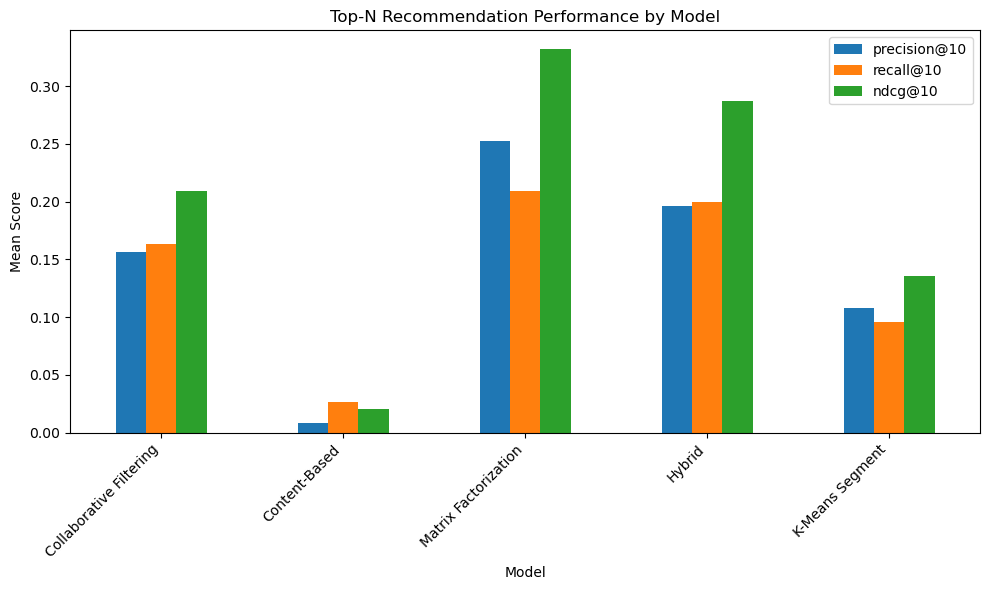

In [ ]:
# Plotting top N metrics
main_metrics = [f"precision@{K}", f"recall@{K}", f"ndcg@{K}"]

evaluation_summary[main_metrics].plot(kind="bar", figsize=(10, 6))

plt.title("Top-N Recommendation Performance by Model")
plt.ylabel("Mean Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Matrix Factorization RMSE and MAE

RMSE and MAE were calculated for the matrix factorization model because it directly estimates numerical user ratings for anime. RMSE and MAE compare these predicted ratings to the actual ratings in the test set, allowing us to measure rating-prediction error.

In contrast, the other recommendation models are primarily designed to produce ranked recommendation lists, so they are better evaluated using Precision@K, Recall@K, and NDCG@K.

In [ ]:
# Predicting ratings using Matrix Factorization model
def predict_mf_rating(user_id, anime_id, user_to_idx, anime_to_idx, user_factors, item_factors):
    if user_id not in user_to_idx:
        return np.nan

    if anime_id not in anime_to_idx:
        return np.nan

    user_idx = user_to_idx[user_id]
    anime_idx = anime_to_idx[anime_id]

    pred = user_factors[user_idx] @ item_factors[anime_idx]

    # Keeping predictions within MAL's established rating scale
    pred = np.clip(pred, 1, 10)

    return pred

In [ ]:
def evaluate_mf_rmse_mae(ratings_to_score, user_to_idx, anime_to_idx, user_factors, item_factors, max_rows=50000):
    eval_df = ratings_to_score.copy()

    if max_rows is not None and len(eval_df) > max_rows:
        eval_df = eval_df.sample(max_rows, random_state=random_state)

    preds = []
    actuals = []

    for _, row in eval_df.iterrows():
        pred = predict_mf_rating(
            user_id=row["user_id"],
            anime_id=row["anime_id"],
            user_to_idx=user_to_idx,
            anime_to_idx=anime_to_idx,
            user_factors=user_factors,
            item_factors=item_factors
        )

        if pd.notna(pred):
            preds.append(pred)
            actuals.append(row["rating"])

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "n_evaluated": len(actuals)
    }

In [ ]:
mf_train_eval = evaluate_mf_rmse_mae(
    cf_train_ratings,
    user_to_idx,
    anime_to_idx,
    user_factors,
    item_factors,
    max_rows=50000
)

mf_test_eval = evaluate_mf_rmse_mae(
    test_ratings,
    user_to_idx,
    anime_to_idx,
    user_factors,
    item_factors,
    max_rows=50000
)

mf_rating_summary = pd.DataFrame(
    [mf_train_eval, mf_test_eval],
    index=["Train", "Test"]
)

mf_rating_summary

,RMSE,MAE,n_evaluated
Train,5.259308,4.799292,50000
Test,5.837346,5.512121,43852


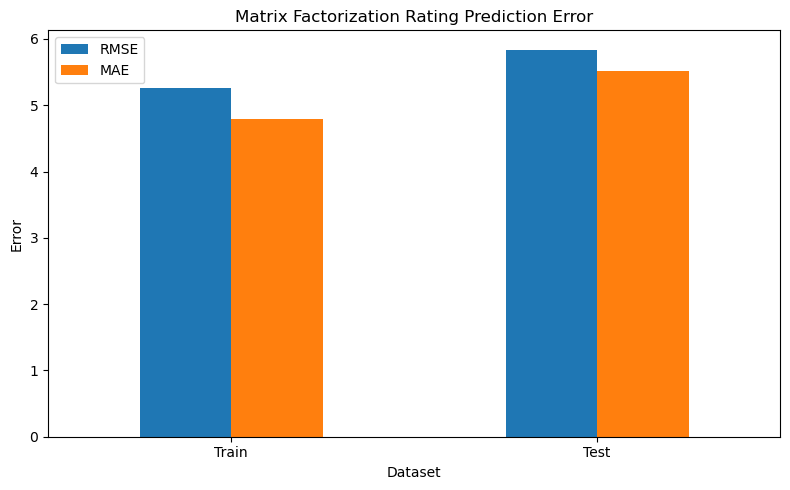

In [ ]:
mf_rating_summary[["RMSE", "MAE"]].plot(kind="bar", figsize=(8, 5))

plt.title("Matrix Factorization Rating Prediction Error")
plt.ylabel("Error")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cold-start evaluation

As our final evaluation metric, we wanted to compare how well our models performed between the well established userbase (i.e. users with a long history of anime watched) – assigned the title ```warm_users``` – versus our much newer users with less anime watched – assigned the title ```cold_users```.

Because our collaborative filtering and matrix factorization models rely much more heavily on past user-item interactions, so they may perform poorly for new or sparse users, and based on our initial objectives of analyzing how well the models can fill the gap of anime recommendations for new users, we wanted to see how well these models performed for the cold users group.

More plainly, this would enable us to determine whether content-based or hybrid models handle sparse-user cases better than the former two models (in addition to the k-means user-segmentation model).

In [ ]:
# Creating cold and warm user groups
train_user_counts = train_ratings["user_id"].value_counts()

cold_users = train_user_counts[train_user_counts <= 5].index
warm_users = train_user_counts[train_user_counts >= 20].index

# Keeping cold and warm users train-test splits consistent with the initial train-test split
cold_test = test_ratings[test_ratings["user_id"].isin(cold_users)]
warm_test = test_ratings[test_ratings["user_id"].isin(warm_users)]

display(cold_test.shape)
display(warm_test.shape)

(292, 8)

(105533, 8)

In [ ]:
# Running models on separate cold and warm groups
cold_warm_summaries = []

for group_name, group_test in [("Cold-Start Users", cold_test), ("Warm Users", warm_test)]:
    for model_name, model_func in model_functions.items():
        print(f"Evaluating {model_name} on {group_name}...")

        _, summary = evaluate_top_n_model(
            model_name=model_name,
            recommender_func=model_func,
            train_ratings=train_ratings,
            test_ratings=group_test,
            anime_meta=anime_meta,
            k=K,
            relevance_threshold=relevance_threshold,
            max_eval_users=max_eval_users
        )

        summary["user_group"] = group_name
        cold_warm_summaries.append(summary)

cold_warm_summary = pd.concat(cold_warm_summaries, ignore_index=True)

cold_warm_summary

Evaluating Collaborative Filtering on Cold-Start Users...
Evaluating Content-Based on Cold-Start Users...
Evaluating Matrix Factorization on Cold-Start Users...
Evaluating Hybrid on Cold-Start Users...
Evaluating K-Means Segment on Cold-Start Users...
Evaluating Collaborative Filtering on Warm Users...
Evaluating Content-Based on Warm Users...
Evaluating Matrix Factorization on Warm Users...
Evaluating Hybrid on Warm Users...
Evaluating K-Means Segment on Warm Users...


,model,precision@10,recall@10,ndcg@10,catalog_coverage,n_evaluated_users,user_group
0,Collaborative Filtering,NaN,NaN,NaN,NaN,0,Cold-Start Users
1,Content-Based,0.017597,0.175966,0.098510,0.051058,233,Cold-Start Users
2,Matrix Factorization,NaN,NaN,NaN,NaN,0,Cold-Start Users
3,Hybrid,0.017597,0.175966,0.098510,0.051058,233,Cold-Start Users
4,K-Means Segment,0.013537,0.135371,0.086336,0.000850,229,Cold-Start Users
5,Collaborative Filtering,0.169076,0.148587,0.212731,0.019703,498,Warm Users
6,Content-Based,0.008032,0.009167,0.010467,0.025304,498,Warm Users
7,Matrix Factorization,0.280723,0.205784,0.345536,0.022803,498,Warm Users
8,Hybrid,0.237349,0.191451,0.319595,0.025954,498,Warm Users
9,K-Means Segment,0.130303,0.096322,0.157026,0.002950,495,Warm Users


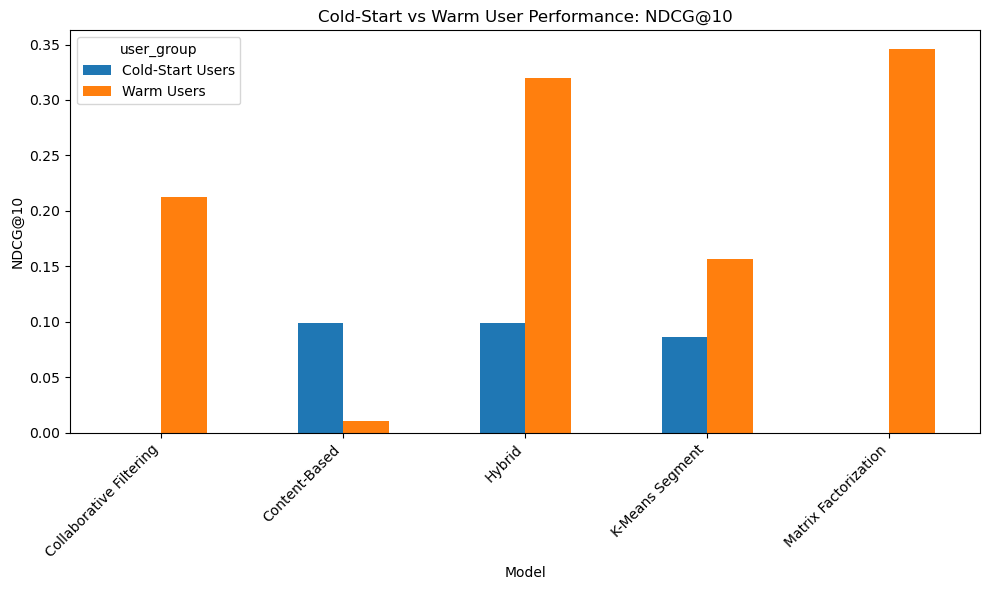

In [ ]:
# Plotting results
cold_warm_pivot = cold_warm_summary.pivot(
    index="model",
    columns="user_group",
    values=f"ndcg@{K}"
)

cold_warm_pivot.plot(kind="bar", figsize=(10, 6))

plt.title(f"Cold-Start vs Warm User Performance: NDCG@{K}")
plt.ylabel(f"NDCG@{K}")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Model Interpretation

Looking at the evaluation results, **matrix factorization performed the strongest overall on the top-N recommendation metrics**. It achieved the highest Precision, Recall, and NDCG among the five evaluated models. This suggests that the latent-factor approach was best able to capture hidden relationships between users and anime titles from the user-item rating matrix. In other words, instead of relying only on obvious similarities such as genre or synopsis, matrix factorization was able to represent users and anime in a lower-dimensional preference space, which helped it recommend titles that aligned with users' ratings yet to be assigned.

The **hybrid recommender produced the second-strongest overall results**. Its performance was lower than matrix factorization alone, but higher than collaborative filtering, content-based filtering, and K-Means segmentation on most of the main ranking metrics. This suggests that combining multiple recommendation signals was useful, even if the weighting scheme was not fully optimized. The hybrid model likely benefited from matrix factorization and collaborative filtering for users with enough rating history, while still retaining some content-based information from anime metadata. However, because the hybrid model used fixed weights rather than tuned or learned weights, it may not have reached its best possible performance.

Collaborative filtering also performed reasonably well, especially compared with content-based filtering and K-Means segmentation.
The content-based model had weaker overall performance in the full evaluation, but it performed meaningfully better for cold-start users than collaborative filtering and matrix factorization, which could not evaluate those users at all.

The K-Means user-segment model performed below matrix factorization, hybrid recommendation, and collaborative filtering, but it still provided useful information. Its results suggest that clustering users by viewing behavior can identify broad user groups, but these clusters may be too general to produce highly personalized recommendations. The very low catalog coverage for K-Means also indicates that the model tended to recommend a narrow set of anime within each cluster, which limits recommendation diversity.

Overall, the results support the original project goal of building an anime recommendation system that is personalized and flexible. Matrix factorization and hybrid recommendation were the strongest approaches for users with sufficient rating history, while content-based filtering was more useful for sparse-user cases. This suggests that a practical anime recommendation system should not rely on one model alone, but should combine rating-based and metadata-based approaches depending on the amount of information available for each user.

# 5. Challenges and Limitations – Byron
---
- Discuss any challenges encountered during the project, such as:
  * Issues with data quality or availability.
  * Computational or tool constraints.
  * Model-related challenges like overfitting, underfitting, or feature importance.
- Highlight limitations in your analysis or models and how they might affect your conclusions.

This project came with several challenges related to data quality, preprocessing, and recommendation system design. One of the biggest issues was missing and inconsistent data across the anime and user datasets. In the anime dataframe, several columns contained "UNKNOWN" values, while others had mixed data types that required conversion before analysis. For example, numeric fields such as Score, Episodes, Rank, and Scored By had to be cleaned and converted into usable numeric formats, and some text fields needed to be standardized before they could be used for feature engineering.

Another challenge was the presence of duplicate or overlapping information. Some anime titles appeared in multiple forms, such as Japanese names, English names, or alternate titles. In addition, some synopses were repeated or missing entirely, which limited how much descriptive information could be used for content-based filtering. Because of this, the quality of the recommendation features depended heavily on how well the data was cleaned.

The user dataset also had important limitations. A large number of user records contained at least one missing value, especially in fields such as gender and birthday. Because these fields were incomplete, they were less reliable for direct modeling than the user-rating interactions in the score dataset. As a result, the project relied more heavily on user behavior variables, such as rating history and viewing activity, than on personal demographic information.

Computational constraints were another concern. The user score dataset contains over 24 million rows, which makes it expensive to process and evaluate at full scale. Recommendation systems also face the cold-start problem, meaning they struggle to make good recommendations for new users or anime with little rating history. Collaborative filtering works best when enough interaction data exists, but it becomes weaker when users or items have limited ratings. On the other hand, content-based filtering depends on the quality of item features such as genre, synopsis, type, source, and other anime metadata, which can also be incomplete.

The size of the data also affected the tools we were able to use. The original goal was to keep the project fully contained in a shareable Colab notebook, but the size of the user-score dataset made this difficult. Because the ratings data contained more than 24 million rows, loading, processing, filtering, and evaluating the models required more local control over the computing environment. As a result, much of the final implementation had to be run in VS Code rather than entirely through Colab. This helped make the project more manageable during development, but it also created a limitation for reproducibility because the notebook became more dependent on the local environment, file paths, and package versions used during execution.

The time horizon of the project also limited how much model tuning could be completed. Several models required substantial processing time, especially collaborative filtering, matrix factorization, hybrid recommendation, and K-Means clustering. Because of this, the project focused more on building and comparing functioning versions of each model than on exhaustive hyperparameter tuning. For example, the number of neighbors in the collaborative filtering model, the number of latent components in matrix factorization, the number of clusters in K-Means, and the weighting scheme in the hybrid recommender were chosen using reasonable starting values rather than a full grid-search or repeated cross-validation procedure.

Another limitation is that the final evaluation did not include a fully implemented popularity baseline. A popularity baseline would have been useful because it would show whether the personalized models meaningfully improved on simply recommending highly rated or highly watched anime. Without that baseline, the results still allow comparison among the implemented recommender models, but they do not fully show how much personalization improves over a simple non-personalized recommendation strategy. Future versions of the project should include a popularity-based recommender as a benchmark.

Finally, this project is limited by scope. It focuses on anime recommendation using MyAnimeList-style data, so the conclusions are most applicable to that domain. Although the project implemented several recommendation approaches, it did not test every possible model discussed in the course, such as association rule mining, random forest-based ranking, or neural-network recommendation methods. Because the notebook emphasized data preparation, model design, and model comparison more than final hyperparameter optimization, future work should include deeper model comparison, more robust validation, and stronger performance reporting.

# 6. Conclusion and Future Direction – Byron
---
- Conclusions: Summarize your main findings in relation to your project objectives.
- Recommendation and Future Direction:
  - Propose actions based on your findings.
  - Suggest next steps for further analysis or research.

This project showed that anime recommendation can be approached effectively using both collaborative filtering and content-based filtering. The dataset provided a strong foundation for this work because it included a large anime catalog, detailed user profiles, and millions of user ratings. Together, these datasets made it possible to examine both item characteristics and user behavior, which are both important for building personalized recommendations.

From the data description and cleaning process, it became clear that anime features such as genre, type, score, popularity, favorites, synopsis, and user ratings can all contribute to recommendation quality. The user data also showed that different users have different levels of engagement with anime, which suggests that user experience and viewing history should play an important role in recommendation design. Because of this, a hybrid recommendation system is the most practical direction for the project. Collaborative filtering can capture hidden preference patterns from user ratings, while content-based filtering can help recommend anime with similar features and improve recommendations for users or titles with less rating history.

Overall, the project supports the idea that no single recommendation method is enough on its own. Collaborative filtering is powerful when there is enough interaction data, but content-based filtering is valuable when rating information is sparse. Combining both methods gives the system more flexibility and makes it more useful across different user types.

The model results also clarified which recommendation strategies were most useful under different conditions. Matrix factorization was the strongest overall model based on Precision@10, Recall@10, and NDCG@10, which suggests that latent user-item patterns were especially important in this dataset. The hybrid recommender was also strong, indicating that combining multiple sources of recommendation information can improve flexibility. However, the cold-start evaluation showed that collaborative filtering and matrix factorization were not useful for users with very limited rating history, while content-based filtering and K-Means segmentation were still able to generate recommendations for those users. This reinforces the importance of designing recommendation systems that adapt to the available information for each user.

These results suggest that the best future version of this system would use a conditional hybrid design. For users with many ratings, the system could rely more heavily on matrix factorization and collaborative filtering because these methods performed best when user history was available. For newer or sparse users, the system could rely more on content-based filtering, metadata similarity, and possibly cluster-based recommendations until enough rating history is collected. This would allow the recommender to handle both experienced anime viewers and newer users more effectively.

For future work, this project could be improved in several ways. First, the hybrid recommender could be improved by tuning or learning the weights assigned to collaborative filtering, content-based filtering, and matrix factorization scores rather than using fixed starting values. Second, additional feature engineering could be added from synopsis text, studios, release information, and title-based features to improve item similarity. Third, more advanced modeling techniques such as neural recommendation methods, learned ranking models, or text embeddings could be tested. Fourth, evaluation could be strengthened by adding repeated train-test splits, MAP@K, novelty (measuring the "newness" of a given user's recommendations), serendipity (measuring a sort of "surprise factor" for a given user's recommendation), and more detailed error analysis. Lastly, future versions of the system could explore implicit feedback, such as watch history, favorites, dropped status, or plan-to-watch behavior, to make recommendations even more personalized.

Future work should also include a popularity baseline so that the personalized models can be compared against a simple non-personalized benchmark. In addition, the models should be tuned more systematically. For example, future versions could test different values for K in collaborative filtering, different numbers of latent factors in matrix factorization, different numbers of K-Means clusters, and different hybrid model weights. A more complete version could also use repeated validation to determine whether the results are stable across different user samples.

Finally, future work could improve reproducibility by creating a more portable version of the project. Because the dataset was large, the final implementation was run through VS Code rather than fully in Colab. A future version could use a smaller sampled dataset for demonstration in Colab, while keeping the full local dataset for final model training. This would make the project easier to share and reproduce while still preserving the ability to train models on the larger dataset.

# 7. References – Byron
---
- List all references for datasets, tools, and external sources used in the project.

Dhinakaran, A. (n.d.). Demystifying NDCG: How to best use this important metric for monitoring ranking models. Medium.
https://medium.com/data-science/demystifying-ndcg-bee3be58cfe0

Google Colab. (n.d.). *Google Colaboratory*.  
https://colab.research.google.com/

Kaggle. (2023). *MyAnimeList dataset* (anime-dataset-2023.csv, users-details-2023.csv, users-score-2023.csv).  
https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset/data?select=anime-dataset-2023.csv

MyAnimeList. (n.d.). *Top anime*.  
https://myanimelist.net/topanime.php

MyAnimeList. (n.d.). *Top anime scoring formula / information page*.  
https://myanimelist.net/info.php?go=topanime

NumPy developers. (n.d.). *NumPy documentation*.  
https://numpy.org/doc/

pandas development team. (n.d.). *pandas documentation*.  
https://pandas.pydata.org/docs/

Scikit-learn developers. (n.d.). sklearn.metrics.ndcg_score. Scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html

To see the files in your current directory, you can use the `!ls -F` command: